In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib as mpl

sys.path.append(r"D:\CPD_MPIA\CPD_Emission_Models")
os.chdir(r"D:\CPD_MPIA\CPD_Emission_Models")   # caches live relative to cwd
import Zhu_model, Andrew_model
from Dictionaries import disk_arr

rcParams["font.size"] = 22
rcParams["font.family"] = "serif"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"

def _clim(m):
    if m is None:
        return None
    if hasattr(m, "get_clim"):
        return m.get_clim()
    if hasattr(m, "collections") and m.collections:
        return m.collections[0].get_clim()
    return None

def _apply_norm(m, norm):
    if m is None:
        return
    if hasattr(m, "set_norm"):
        m.set_norm(norm)
        return
    if hasattr(m, "collections") and m.collections:
        for c in m.collections:
            c.set_norm(norm)

def add_row_colorbar(fig, axes_row, mapps, label, pad=0.02, fraction=0.046, vmin=None, vmax=None):
    mapps = [m for m in mapps if m is not None]
    clims = [c for c in (_clim(m) for m in mapps) if c is not None]
    if not clims:
        return None
    if vmin is None:
        vmin = min(c[0] for c in clims)
    if vmax is None:
        vmax = max(c[1] for c in clims)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    for m in mapps:
        _apply_norm(m, norm)
    cmap = getattr(mapps[0], "cmap", mpl.cm.viridis)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cb = fig.colorbar(sm, ax=list(axes_row), fraction=fraction, pad=pad)
    cb.set_label(label, fontsize=rcParams["font.size"])
    cb.ax.tick_params(labelsize=rcParams["font.size"] * 0.9)
    return cb

# n_jobs for the Andrews grid computation -- kept low (2) since running many
# disks back-to-back at n_jobs=4+ pegs a laptop's CPU for the whole notebook run
ANDREWS_N_JOBS = 2
ANDREWS_NPZ_DIR = "Andrews_npz"

def get_andrews_grid(disk_name, disk_radius, sigma_ujy, mode, alpha=1e-3, mcpd_max=-3):
    """Andrews (Mp, Rout/R_Hill) grid, cached to .npz -- so re-running this cell
    later just to tweak plot style (colors, ranges, labels) never recomputes."""
    os.makedirs(ANDREWS_NPZ_DIR, exist_ok=True)
    # mcpd_max: top of the CPD-mass search grid (log10 M_Jup); cells needing more mass stay white.
    # Only a non-default value goes into the file name, so the existing caches stay valid.
    tag = "" if mcpd_max == -3 else f"_mcpdmax{mcpd_max}"
    npz_path = f"{ANDREWS_NPZ_DIR}/{disk_name}_{disk_radius}_alpha{alpha}_{mode}{tag}.npz"
    if os.path.exists(npz_path):
        d = np.load(npz_path)
        return d["Mp_grid"], d["Rout_frac_grid"], d["Flux_vals"], d["M_cpd_chosen"]

    Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen = Andrew_model.compute_flux_map(
        target_flux_arr=[sigma_ujy], disk_arr=disk_arr[disk_name],
        rp=disk_radius, alpha=alpha, mode=mode, verbose=False, mcpd_max=mcpd_max,
        save=False, n_jobs=ANDREWS_N_JOBS,
    )
    np.savez(npz_path, Mp_grid=Mp_grid, Rout_frac_grid=Rout_frac_grid,
             Flux_vals=Flux_vals, M_cpd_chosen=M_cpd_chosen)
    return Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen

def get_zhu_mpmdot_grid(disk_name, disk_radius, mode, alpha=1e-3,
                         mp_min=-2, mp_max=1, n_mp=100,
                         mdot_min=-8, mdot_max=-5, n_mdot=100):
    """Zhu (Mp, Mdot) flux grid, cached to .npz -- same convention as get_andrews_grid.
    Also returns Tau_vals2 (tau_mm at the disk's inner edge -- Zhu_model's own
    Tb_from_tau uses exactly this tau_mm to switch between the optically-thick
    branch, Tb=((3/8)(kappaR/kappa_mm)Teff^4+Text^4)^0.25 -- no Sigma dependence,
    heating-dominated -- and the thin branch, Tb=2*tau*Tc -- linear in Sigma via
    tau=0.5*kappa_mm*Sigma. So tau=0.5 IS the model's real thick/thin switch,
    not an external threshold -- kept available here even though it's not
    currently plotted, pulled from the same calculate_disk_properties_zhu call
    already made for Flux_vals2 so there's no extra cost to keeping it)."""
    os.makedirs(ANDREWS_NPZ_DIR, exist_ok=True)
    npz_path = (f"{ANDREWS_NPZ_DIR}/{disk_name}_{disk_radius}_zhu_mpmdot_{mode}"
                f"_a{alpha}_mp{mp_min}_{mp_max}_{n_mp}_md{mdot_min}_{mdot_max}_{n_mdot}.npz")
    if os.path.exists(npz_path):
        d = np.load(npz_path)
        if "Tau_vals2" in d.files:
            return d["Mp_grid2"], d["Mdot_grid"], d["Flux_vals2"], d["Tau_vals2"]

    Mp_grid2 = np.logspace(mp_min, mp_max, n_mp)
    Mdot_grid = np.logspace(mdot_min, mdot_max, n_mdot)
    Flux_vals2 = np.zeros((len(Mdot_grid), len(Mp_grid2)))
    Tau_vals2 = np.zeros((len(Mdot_grid), len(Mp_grid2)))
    for i, Mdot in enumerate(Mdot_grid):
        for j, Mp in enumerate(Mp_grid2):
            RHill = disk_radius * (Mp / (3 * 1047.56 * disk_arr[disk_name][1])) ** (1 / 3)
            out = Zhu_model.calculate_disk_properties_zhu(
                M_star=disk_arr[disk_name][1], Mp=Mp, Mdot=Mdot, alpha=alpha,
                rp=disk_radius, d_pc=disk_arr[disk_name][2], lam_mm=0.9,
                Rout=0.3 * RHill, Lstar=disk_arr[disk_name][3],
            )
            Flux_vals2[i, j] = out["F_nu_tot"]
            Tau_vals2[i, j] = out["tau_mm"][0]
    np.savez(npz_path, Mp_grid2=Mp_grid2, Mdot_grid=Mdot_grid, Flux_vals2=Flux_vals2, Tau_vals2=Tau_vals2)
    return Mp_grid2, Mdot_grid, Flux_vals2, Tau_vals2

def get_zhu_mpalpha_grid(disk_name, disk_radius, mode,
                          mp_min=-2, mp_max=1, n_mp=80,
                          alpha_min=-4, alpha_max=-1, n_alpha=80,
                          Mdot=None):
    """Zhu (Mp, alpha) flux grid, cached to .npz -- same convention as get_andrews_grid.
    Mdot=None (default): Zhu_model uses its Mdot=Mp/1e6 scaling. Pass a fixed
    value (Mjup/yr) to hold Mdot constant across the grid instead.
    Also returns Tau_map (tau_mm at the disk's inner edge, see get_zhu_mpmdot_grid's
    docstring -- kept available, not currently plotted) -- looped directly
    (rather than via Zhu_model.compute_flux_map_zhu_MpAlpha) so we can pull
    tau_mm out of the same calculate_disk_properties_zhu call without touching
    that shared function's return signature, which other notebooks rely on."""
    os.makedirs(ANDREWS_NPZ_DIR, exist_ok=True)
    npz_path = (f"{ANDREWS_NPZ_DIR}/{disk_name}_{disk_radius}_zhu_mpalpha_{mode}"
                f"_mp{mp_min}_{mp_max}_{n_mp}_al{alpha_min}_{alpha_max}_{n_alpha}_md{Mdot}.npz")
    if os.path.exists(npz_path):
        d = np.load(npz_path)
        if "Tau_map" in d.files:
            return d["Mp_grid_alpha"], d["alpha_grid"], d["Flux_map"], d["Tau_map"]

    Mp_grid_alpha = np.logspace(mp_min, mp_max, n_mp)
    alpha_grid = np.logspace(alpha_min, alpha_max, n_alpha)
    Flux_map = np.zeros((n_alpha, n_mp))
    Tau_map = np.zeros((n_alpha, n_mp))
    M_star_jup = disk_arr[disk_name][1] * 1047.56
    for j, Mp in enumerate(Mp_grid_alpha):
        RHill = disk_radius * (Mp / (3 * M_star_jup)) ** (1 / 3)
        Rout = 0.3 * RHill
        for i, alpha_val in enumerate(alpha_grid):
            Mdot_use = (Mp / 1e6) if (Mdot is None) else Mdot
            out = Zhu_model.calculate_disk_properties_zhu(
                M_star=disk_arr[disk_name][1], Mp=Mp, Mdot=Mdot_use, alpha=alpha_val,
                rp=disk_radius, d_pc=disk_arr[disk_name][2], lam_mm=0.9,
                Rout=Rout, Lstar=disk_arr[disk_name][3],
            )
            Flux_map[i, j] = out["F_nu_tot"]
            Tau_map[i, j] = out["tau_mm"][0]
    np.savez(npz_path, Mp_grid_alpha=Mp_grid_alpha, alpha_grid=alpha_grid, Flux_map=Flux_map, Tau_map=Tau_map)
    return Mp_grid_alpha, alpha_grid, Flux_map, Tau_map

def heating_vs_sigma_slope(alpha_grid, Flux_map):
    """d(ln F)/d(ln alpha) at fixed Mdot, from row 3's own flux grid -- a
    complementary check to tau=0.5: alpha's only job in the Zhu model is
    setting Sigma, never the heating rate, so slope~0 confirms heating-
    dominated (tau>0.5 branch) and slope~-1 confirms Sigma-dominated (tau<0.5
    branch). Used by the summary-table cells below."""
    return np.gradient(np.log(Flux_map), np.log(alpha_grid), axis=0)

def plot_emission_grid(
    sources, mode, planet_masses=None,
    # Row 1 -- Andrews: Mp vs Rout/R_Hill
    andrews_alpha=1e-3, andrews_x_min=-2, andrews_x_max=1,
    andrews_y_min=0.05, andrews_y_max=0.8,
    andrews_cmin=-5.5, andrews_cmax=-2.5,
    andrews_mcpd_max=-3,   # top of the CPD-mass search (log10 M_Jup), see get_andrews_grid
    # Row 2 -- Zhu: Mp vs Mdot
    zhu2_alpha=1e-3,
    zhu2_mp_min=-2, zhu2_mp_max=1, zhu2_n_mp=100,
    zhu2_mdot_min=-8, zhu2_mdot_max=-5, zhu2_n_mdot=100,
    # per-column viscosity override for row 2 -- {(disk_name, disk_radius): alpha},
    # falls back to zhu2_alpha where absent. Panel is annotated with the
    # overridden value so the change is visible on the plot.
    zhu2_alpha_by_col=None,
    # Row 3 -- Zhu: Mp vs alpha
    zhu3_mp_min=-2, zhu3_mp_max=1, zhu3_n_mp=80,
    zhu3_alpha_min=-4, zhu3_alpha_max=-1, zhu3_n_alpha=80,
    # per-column fixed-Mdot override for row 3 -- {(disk_name, disk_radius): Mdot_Mjup_per_yr},
    # replaces the default Mdot=Mp/1e6 scaling with a constant accretion rate
    # (e.g. the row-2 F50 intersection value). Panel is annotated when set.
    zhu3_mdot_by_col=None,
    # shared row colorbars -- row 1 defaults to andrews_cmin/andrews_cmax (same
    # values used for each panel's own contourf levels); rows 2/3 default to
    # None, which auto-scales from the plotted data as before
    zhu2_cbar_vmin=None, zhu2_cbar_vmax=None,
    zhu3_cbar_vmin=None, zhu3_cbar_vmax=None,
    # optional {(disk_name, disk_radius): gap_boundary_au} -- hatches the
    # region on row 1 where R_cpd > this boundary (e.g. 2*wgap for a real
    # gap; keyed by (disk_name, radius) since one disk can have >1 gap in
    # the same sources list. No natural analog for kinks -- omit the entry
    # to skip it there.
    gap_boundary_au=None,
    # optional {(disk_name, disk_radius): mass_Mjup} -- draws a magenta dashed
    # vertical line with a left-pointing arrow on every row, indicating an
    # upper limit (Mp < value) rather than a fixed estimate. Distinct from
    # planet_masses below since a single disk can have multiple columns here.
    mass_upper_limits=None,
    # set False to skip the faint dashed Mp=1 Mjup reference line -- redundant
    # once a magenta planet_masses/mass_upper_limits line is already drawn
    # (e.g. the kink candidate plots)
    show_mp1_line=True,
):
    """sources: list of (disk_name, radius_au, flux_ujy). mode: cache-file tag (e.g. 'gap', 'kink').
    planet_masses: optional {disk_name: mass_Mjup} or {(disk_name, disk_radius): mass_Mjup}
    -- draws a magenta vertical line at that mass on every row (all three rows
    share a log10(Mp) x-axis). The tuple-key form disambiguates multiple
    columns of the same disk_name; disk_name-only keys apply to every column
    of that disk (original behavior).
    mass_upper_limits: see above -- upper-limit arrow variant, tuple-keyed only.
    All defaults match the original hardcoded values -- pass any of the
    andrews_*/zhu2_*/zhu3_* kwargs to override without editing this function."""
    fig, axes = plt.subplots(3, len(sources), figsize=(6 * len(sources), 15), sharex=False, sharey=False, constrained_layout=True)
    if len(sources) == 1:
        axes = axes[:, None]
    row_mappables = [[], [], []]

    for col, (disk_name, disk_radius, sigma_ujy) in enumerate(sources):
        axes[0, col].set_title(
            f"{disk_name.replace('_',' ')} (r={disk_radius:.0f} au)",
            fontsize=rcParams["font.size"], pad=10, fontweight="bold",
        )

        # ROW 1 -- Andrews: Mp vs Rout/R_Hill, colored by log10(M_CPD)
        ax = axes[0, col]
        ax.set_aspect("auto")
        Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen = get_andrews_grid(
            disk_name, disk_radius, sigma_ujy, mode, alpha=andrews_alpha, mcpd_max=andrews_mcpd_max,
        )
        im = Andrew_model.plot_flux_map(
            Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen,
            disk_arr=disk_arr[disk_name], ax=ax,
            rp=disk_radius, alpha=andrews_alpha,
            x_min=andrews_x_min, x_max=andrews_x_max, y_min=andrews_y_min, y_max=andrews_y_max,
            min=andrews_cmin, max=andrews_cmax,
            res_au=disk_arr[disk_name][4] * disk_arr[disk_name][2],
            sigma_ujy=sigma_ujy, det_sigma=5,
            gap_boundary_au=(gap_boundary_au or {}).get((disk_name, disk_radius)),
        )
        row_mappables[0].append(im)
        ax.text(0.05, 0.05, rf"F50={sigma_ujy:.0f} $\mu$Jy", transform=ax.transAxes, ha="left", va="bottom",
                 color="black", fontsize=rcParams["font.size"] * 0.7)

        # ROW 2 -- Zhu: Mp vs Mdot, colored by log10(flux). The Mp*Mdot=const
        # dash-dot hyperbolas (drawn by plot_zhu_Mp_Mdot_flux itself) are the
        # diagnostic here -- both heating channels scale as Mp*Mdot, so how
        # closely the F50 contour tracks those lines shows whether accretion
        # luminosity alone sets the flux.
        ax = axes[1, col]
        ax.set_aspect("auto")
        bmaj = disk_arr[disk_name][4]  # arcsec
        zhu2_alpha_col = (zhu2_alpha_by_col or {}).get((disk_name, disk_radius), zhu2_alpha)
        Mp_grid2, Mdot_grid, Flux_vals2, Tau_vals2 = get_zhu_mpmdot_grid(
            disk_name, disk_radius, mode, alpha=zhu2_alpha_col,
            mp_min=zhu2_mp_min, mp_max=zhu2_mp_max, n_mp=zhu2_n_mp,
            mdot_min=zhu2_mdot_min, mdot_max=zhu2_mdot_max, n_mdot=zhu2_n_mdot,
        )
        im = Zhu_model.plot_zhu_Mp_Mdot_flux(
            Mp_grid2, Mdot_grid, Flux_vals2,
            disk_arr=disk_arr[disk_name], rp=disk_radius, alpha=zhu2_alpha_col,
            target_flux_arr=[sigma_ujy], ax=ax,
            beam_major_arcsec=bmaj, plot_thick_thin=False,
        )
        row_mappables[1].append(im)
        if zhu2_alpha_col != zhu2_alpha:
            ax.text(0.05, 0.95, rf"$\alpha$ = {zhu2_alpha_col:.0e}", transform=ax.transAxes,
                     ha="left", va="top", color="black", fontsize=rcParams["font.size"] * 0.7,
                     bbox=dict(boxstyle="round", fc="white", ec="none", alpha=0.7))

        # ROW 3 -- Zhu: Mp vs alpha, colored by log10(flux). No overlay -- read
        # the F50 boundary's own shape: vertical (Mp threshold doesn't move with
        # alpha) = heating-dominated; diagonal (threshold shifts with alpha) =
        # Sigma/opacity-dominated.
        ax = axes[2, col]
        ax.set_aspect("auto")
        zhu3_mdot_col = (zhu3_mdot_by_col or {}).get((disk_name, disk_radius))
        Mp_grid_alpha, alpha_grid, Flux_map, Tau_map = get_zhu_mpalpha_grid(
            disk_name, disk_radius, mode,
            mp_min=zhu3_mp_min, mp_max=zhu3_mp_max, n_mp=zhu3_n_mp,
            alpha_min=zhu3_alpha_min, alpha_max=zhu3_alpha_max, n_alpha=zhu3_n_alpha,
            Mdot=zhu3_mdot_col,
        )
        im = Zhu_model.plot_zhu_Mp_alpha_flux(
            Mp_grid_alpha, alpha_grid, Flux_map,
            disk_arr=disk_arr[disk_name], rp=disk_radius, Mdot=zhu3_mdot_col,
            target_flux_arr=[sigma_ujy], beam_major_arcsec=bmaj, ax=ax,
        )
        row_mappables[2].append(im)
        if zhu3_mdot_col is not None:
            ax.text(0.05, 0.95, rf"$\dot{{M}}$ = {zhu3_mdot_col:.1e} $M_{{\rm Jup}}\,{{\rm yr}}^{{-1}}$",
                     transform=ax.transAxes, ha="left", va="top", color="black", fontsize=rcParams["font.size"] * 0.7,
                     bbox=dict(boxstyle="round", fc="white", ec="none", alpha=0.7))

        # reference line at Mp = 1 Mjup (log10(Mp)=0) on every row
        if show_mp1_line:
            for row in range(3):
                axes[row, col].axvline(0, color="darkblue", alpha=0.3, ls="--", lw=1.5, zorder=2)

        mass_key = (disk_name, disk_radius) if (disk_name, disk_radius) in (planet_masses or {}) else disk_name
        if planet_masses and mass_key in planet_masses:
            mass = planet_masses[mass_key]
            for row in range(3):
                axes[row, col].axvline(np.log10(mass), color="magenta", ls="--", lw=2, zorder=5)
            axes[0, col].plot([], [], color="magenta", ls="--", lw=2,
                               label=rf"$M_p$ = {mass} $M_{{\rm Jup}}$")
            axes[0, col].legend(fontsize=rcParams["font.size"] * 0.65, loc="upper right")

            # horizontal magenta line at the (Mp=mass) x F50 intersection, rows 2/3
            logmp = np.log10(mass)
            j2 = np.argmin(np.abs(np.log10(Mp_grid2) - logmp))
            order2 = np.argsort(Flux_vals2[:, j2])
            logmdot_F50 = np.interp(np.log10(sigma_ujy), np.log10(Flux_vals2[:, j2][order2]), np.log10(Mdot_grid[order2]))
            axes[1, col].hlines(logmdot_F50, axes[1, col].get_xlim()[0], logmp, color="magenta", ls="--", lw=2, zorder=5,
                                 label=rf"$\dot{{M}}$ = $10^{{{logmdot_F50:.2f}}}$ $M_{{\rm Jup}}\,{{\rm yr}}^{{-1}}$")
            axes[1, col].legend(fontsize=rcParams["font.size"] * 0.65, loc="upper right")

            j3 = np.argmin(np.abs(np.log10(Mp_grid_alpha) - logmp))
            order3 = np.argsort(Flux_map[:, j3])
            logalpha_F50 = np.interp(np.log10(sigma_ujy), np.log10(Flux_map[:, j3][order3]), np.log10(alpha_grid[order3]))
            axes[2, col].hlines(logalpha_F50, axes[2, col].get_xlim()[0], logmp, color="magenta", ls="--", lw=2, zorder=5,
                                 label=rf"$\alpha$ = $10^{{{logalpha_F50:.2f}}}$")
            axes[2, col].legend(fontsize=rcParams["font.size"] * 0.65, loc="upper right")

        ul_key = (disk_name, disk_radius)
        if mass_upper_limits and ul_key in mass_upper_limits:
            mass_ul = mass_upper_limits[ul_key]
            logmp_ul = np.log10(mass_ul)
            for row in range(3):
                ax_row = axes[row, col]
                ax_row.axvline(logmp_ul, color="magenta", ls="--", lw=2, zorder=5)
                ax_row.annotate(
                    "", xy=(logmp_ul - 0.3, 0.9), xycoords=("data", "axes fraction"),
                    xytext=(logmp_ul, 0.9), textcoords=("data", "axes fraction"),
                    arrowprops=dict(arrowstyle="-|>", color="magenta", lw=2), zorder=6,
                )
            axes[0, col].plot([], [], color="magenta", ls="--", lw=2,
                               label=rf"$M_p$ < {mass_ul} $M_{{\rm Jup}}$")
            axes[0, col].legend(fontsize=rcParams["font.size"] * 0.65, loc="upper right")

    add_row_colorbar(fig, axes[0, :], row_mappables[0], label=r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", vmin=andrews_cmin, vmax=andrews_cmax)
    add_row_colorbar(fig, axes[1, :], row_mappables[1], label=r"$\log_{10}(F_\nu\,[\mu\rm{Jy}])$", vmin=zhu2_cbar_vmin, vmax=zhu2_cbar_vmax)
    add_row_colorbar(fig, axes[2, :], row_mappables[2], label=r"$\log_{10}(F_\nu\,[\mu\rm{Jy}])$", vmin=zhu3_cbar_vmin, vmax=zhu3_cbar_vmax)

    row_side_labels = ["Mp vs Rout", "Mp vs Mdot", "Mp vs alpha"]
    for row in range(3):
        axes[row, 0].annotate(
            row_side_labels[row], xy=(0, 0.5), xycoords="axes fraction",
            xytext=(-60, 0), textcoords="offset points",
            ha="right", va="center", rotation="vertical",
            fontsize=rcParams["font.size"] * 0.9, fontweight="bold",
        )

    plt.show()

### This notebook plugs F50 recovery fluxes (and, for the HD_135344B candidates, actual measured fluxes) into the Zhu and Andrews CPD emission models -- covering the eqC1 gaps, eqC1 inner cavities, HD_135344B point candidates, and kink candidates, all in one place.

## Gaps (eqC1, good recovery profile only)

From `injrev_sum_plot.ipynb`'s summary table -- the original 7-disk `Gap` list, all of which have clean F50 crossings. `HD_135344B_gap0` is excluded (recovery never reaches 50%, fixed contaminating residual).

D:\CPD_MPIA\CPD_Emission_Models\Andrew_model.py:369: RuntimeWarning: divide by zero encountered in log10
  np.log10(M_cpd_chosen),


logMp_limit = 4.016303731379216 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.1226490711716886 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.155913523494643 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 3.470615084272021 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.332381186062188 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 3.91190380430342 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 4.215851143706156 xlim = (np.float64(-2.0), np.float64(1.0))


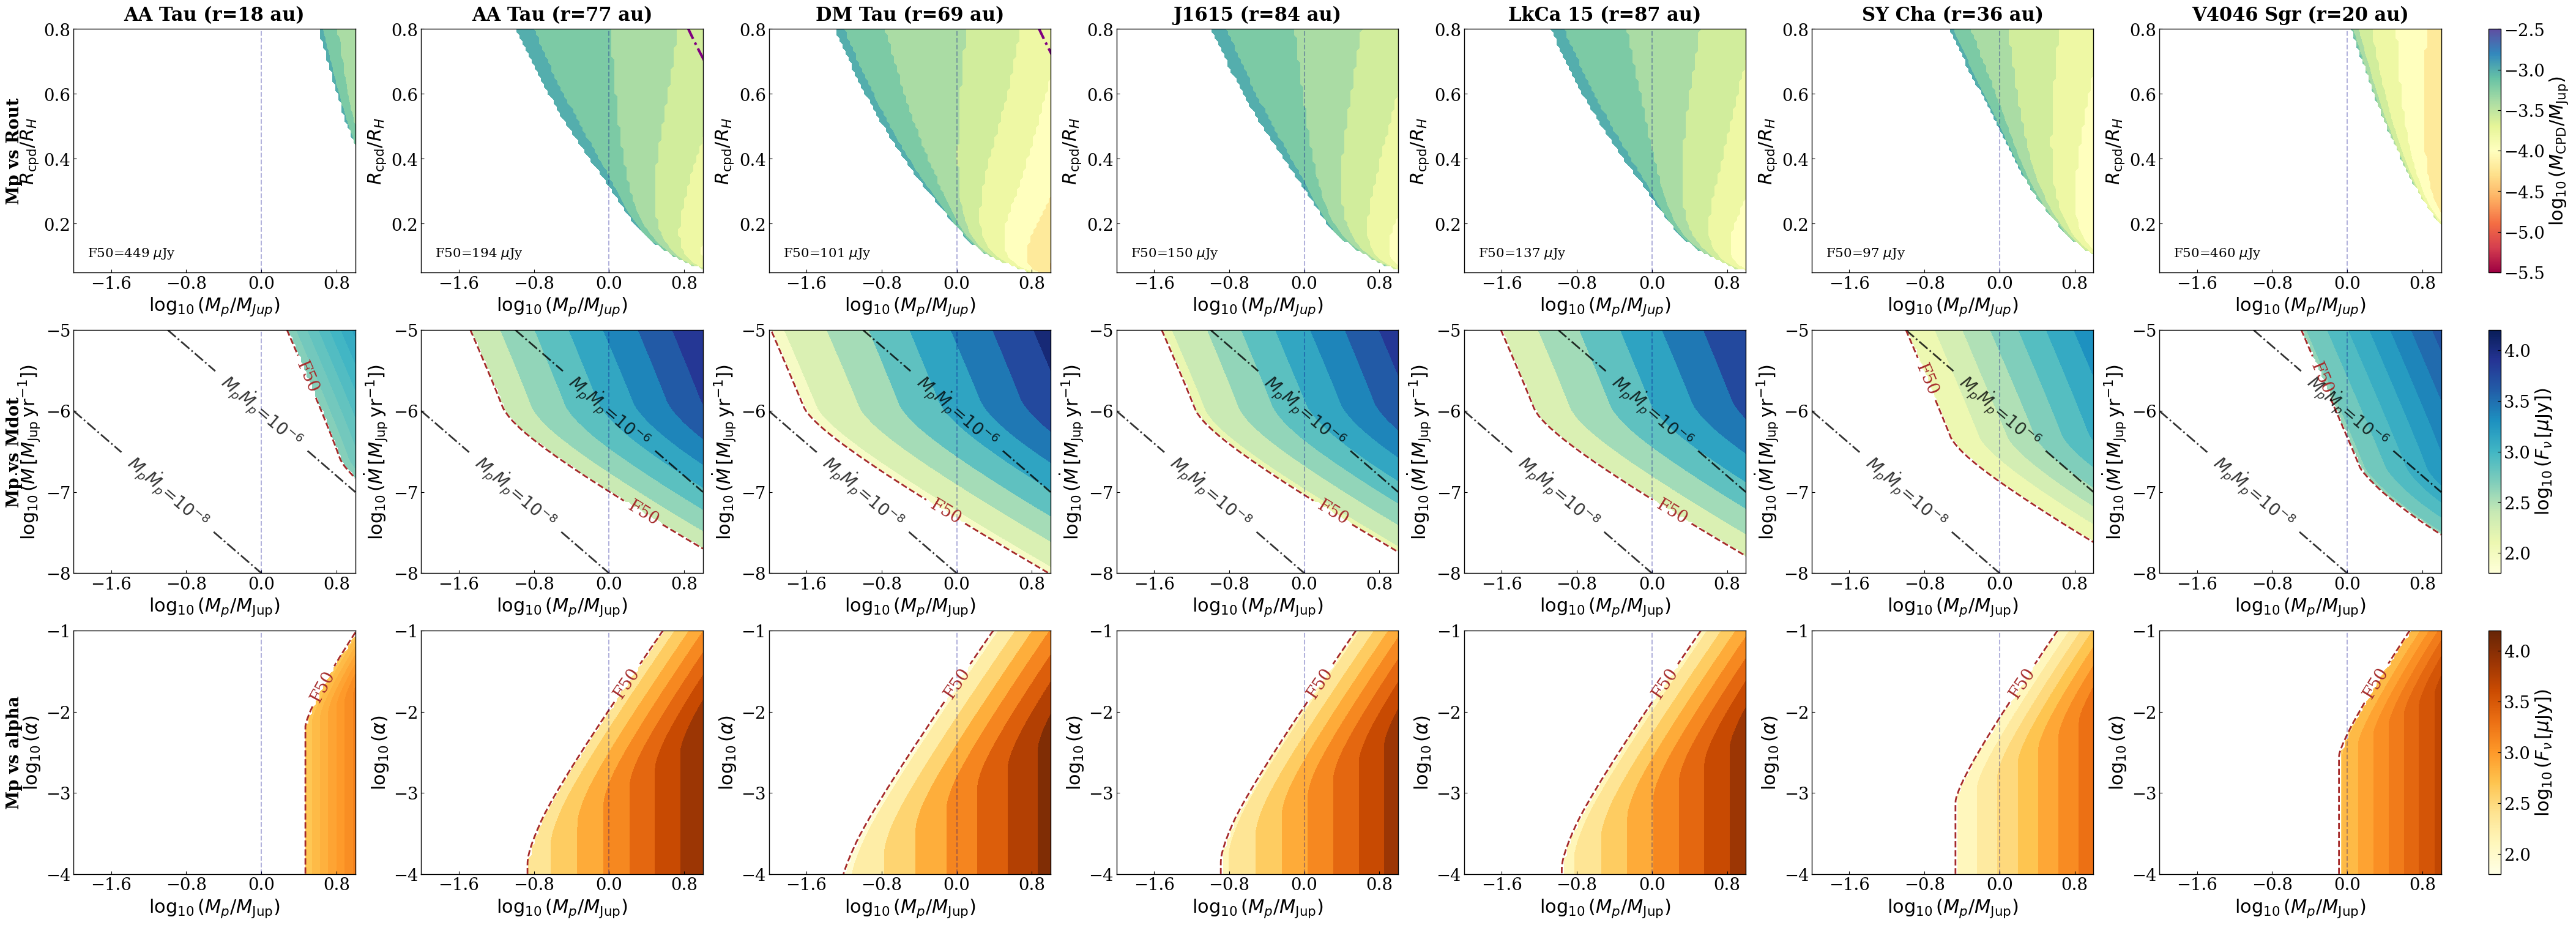

In [2]:
import sys
sys.path.append(r"D:\CPD_MPIA\HPC_eqC1_gap")
import diskdictionary_eqC1 as diskdict

# eqC1 gap F50 values (criterion B), from injrev_sum_plot.ipynb's Gap list -- all clean crossings
# Format: [disk_name, radius_au, F50_ujy]
gap_sources = [
    ["AA_Tau",     18, 449.2],
    ["AA_Tau",     77, 194.0],
    ["DM_Tau",     69, 101.0],
    ["J1615",      84, 150.2],
    ["LkCa_15",    87, 137.0],
    ["SY_Cha",     36,  97.4],
    ["V4046_Sgr",  20, 459.5],
]

# gap-boundary hatch: 2*wgap (sigma_gap) in au, per (disk_name, radius_au) --
# keyed by radius since AA_Tau has two gaps here with different widths
gap_ix_by_source = {
    ("AA_Tau", 18): 0, ("AA_Tau", 77): 1, ("DM_Tau", 69): 1,
    ("J1615", 84): 0, ("LkCa_15", 87): 0, ("SY_Cha", 36): 0, ("V4046_Sgr", 20): 1,
}
gap_boundary_au = {
    (name, r_au): 2 * diskdict.disk[name]["wgap"][gap_ix] * diskdict.disk[name]["distance"]
    for (name, r_au), gap_ix in gap_ix_by_source.items()
}

plot_emission_grid(gap_sources, mode="gap", gap_boundary_au=gap_boundary_au)

## Inner cavities (eqC1, good recovery profile only)

The 8-disk `Inner_cavity` list plus `V4046_Sgr_gap0`, minus `J1615_gap1` (excluded -- its gap radius, 0.04", is smaller than the beam FWHM, so recovery is flat regardless of injected flux and F50 isn't physically meaningful there).

logMp_limit = 5.885080805800041 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 4.434917057563535 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 5.768049897837341 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 3.5028795279501734 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 4.602551622394801 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 5.2882114156000695 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 5.155695612974758 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 5.784487379547168 xlim = (np.float64(-2.0), np.float64(1.0))


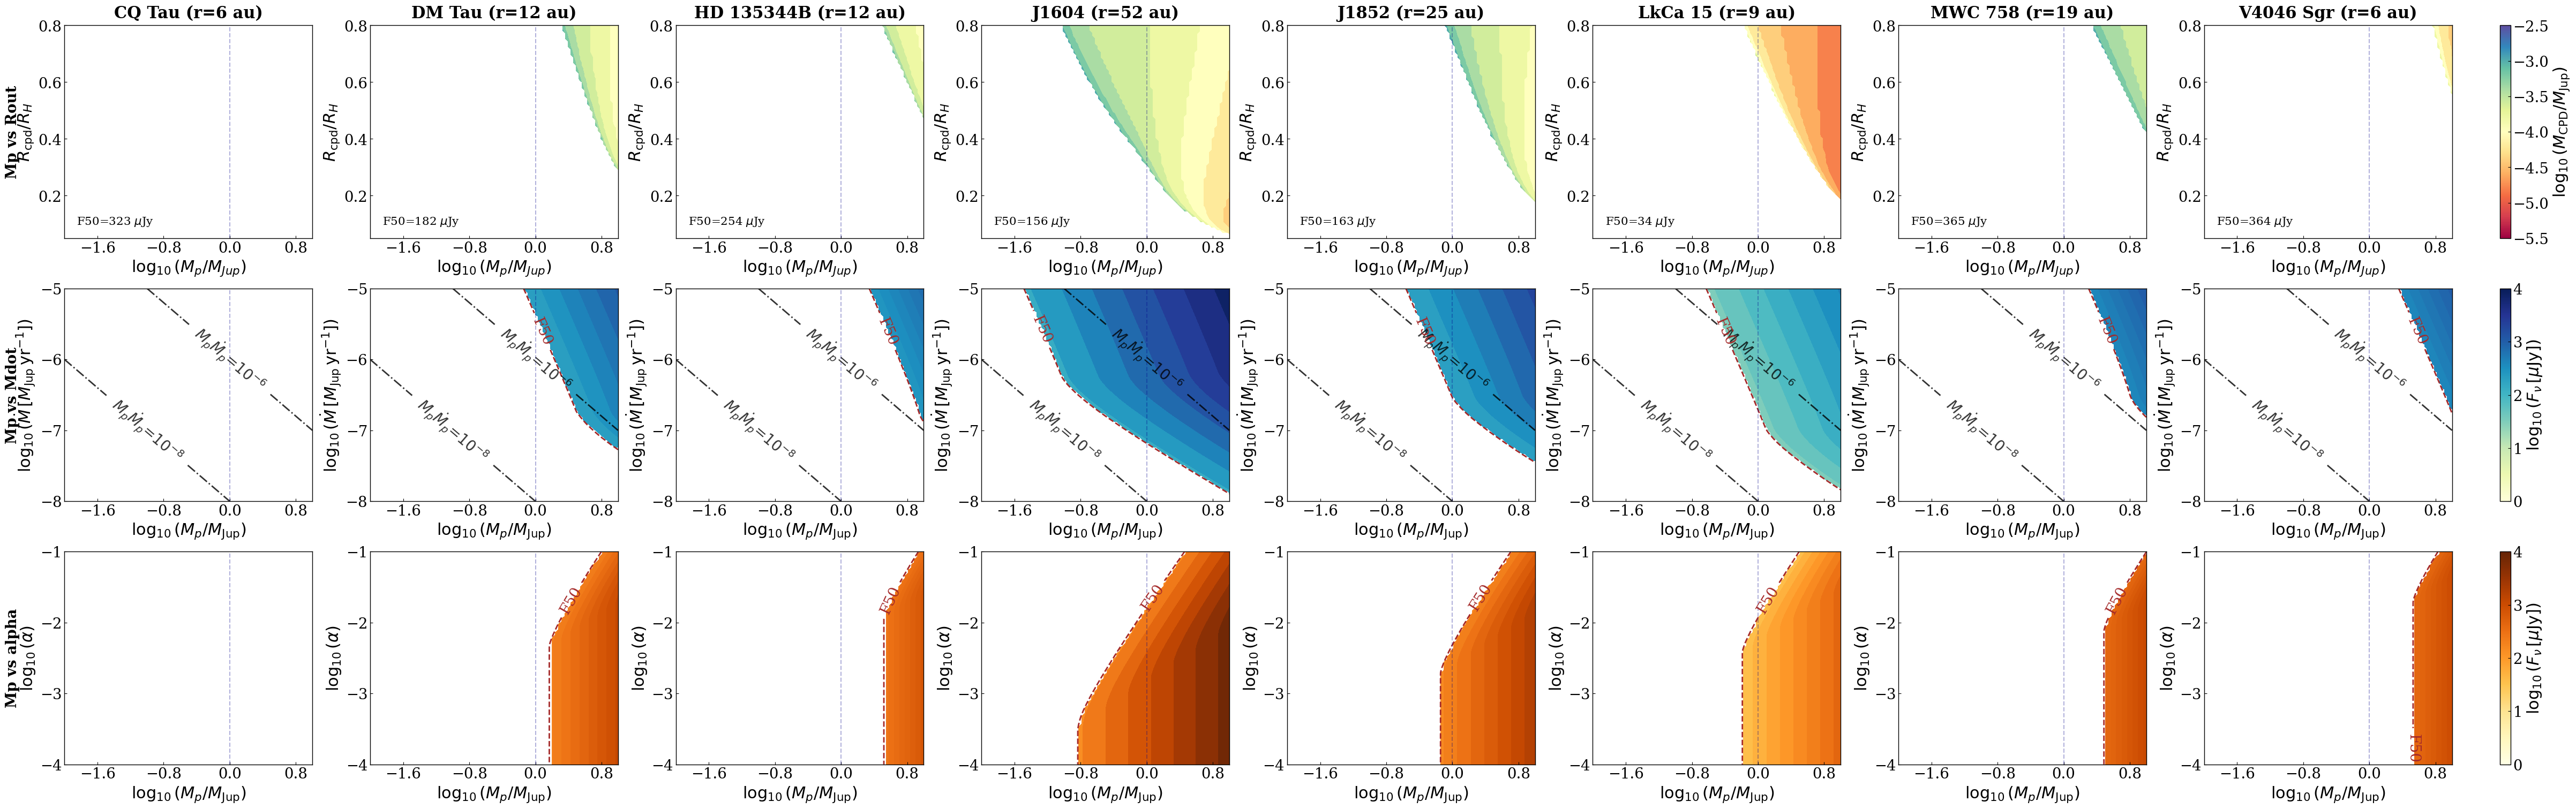

In [3]:
# eqC1 inner-cavity F50 values (criterion B), from injrev_sum_plot.ipynb's InnerCavity_f50 list
# Format: [disk_name, radius_au, F50_ujy]
inner_cavity_sources = [
    ["CQ_Tau",      6, 323.3],
    ["DM_Tau",     12, 182.0],
    ["HD_135344B", 12, 253.6],
    ["J1604",      52, 156.3],
    ["J1852",      25, 163.3],
    ["LkCa_15",     9,  34.0],
    ["MWC_758",    19, 365.1],
    ["V4046_Sgr",   6, 364.0],
]

# gap-boundary hatch: 2*wgap (sigma_gap) in au, per (disk_name, radius_au)
cavity_gap_ix = {
    ("CQ_Tau", 6): 0, ("DM_Tau", 12): 0, ("HD_135344B", 12): 1, ("J1604", 52): 0,
    ("J1852", 25): 0, ("LkCa_15", 9): 1, ("MWC_758", 19): 0, ("V4046_Sgr", 6): 0,
}
cavity_boundary_au = {
    (name, r_au): 2 * diskdict.disk[name]["wgap"][gap_ix] * diskdict.disk[name]["distance"]
    for (name, r_au), gap_ix in cavity_gap_ix.items()
}

plot_emission_grid(inner_cavity_sources, mode="innercav", gap_boundary_au=cavity_boundary_au)

logMp_limit = 4.016303731379216 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.1226490711716886 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.155913523494643 xlim = (np.float64(-2.0), np.float64(1.0))


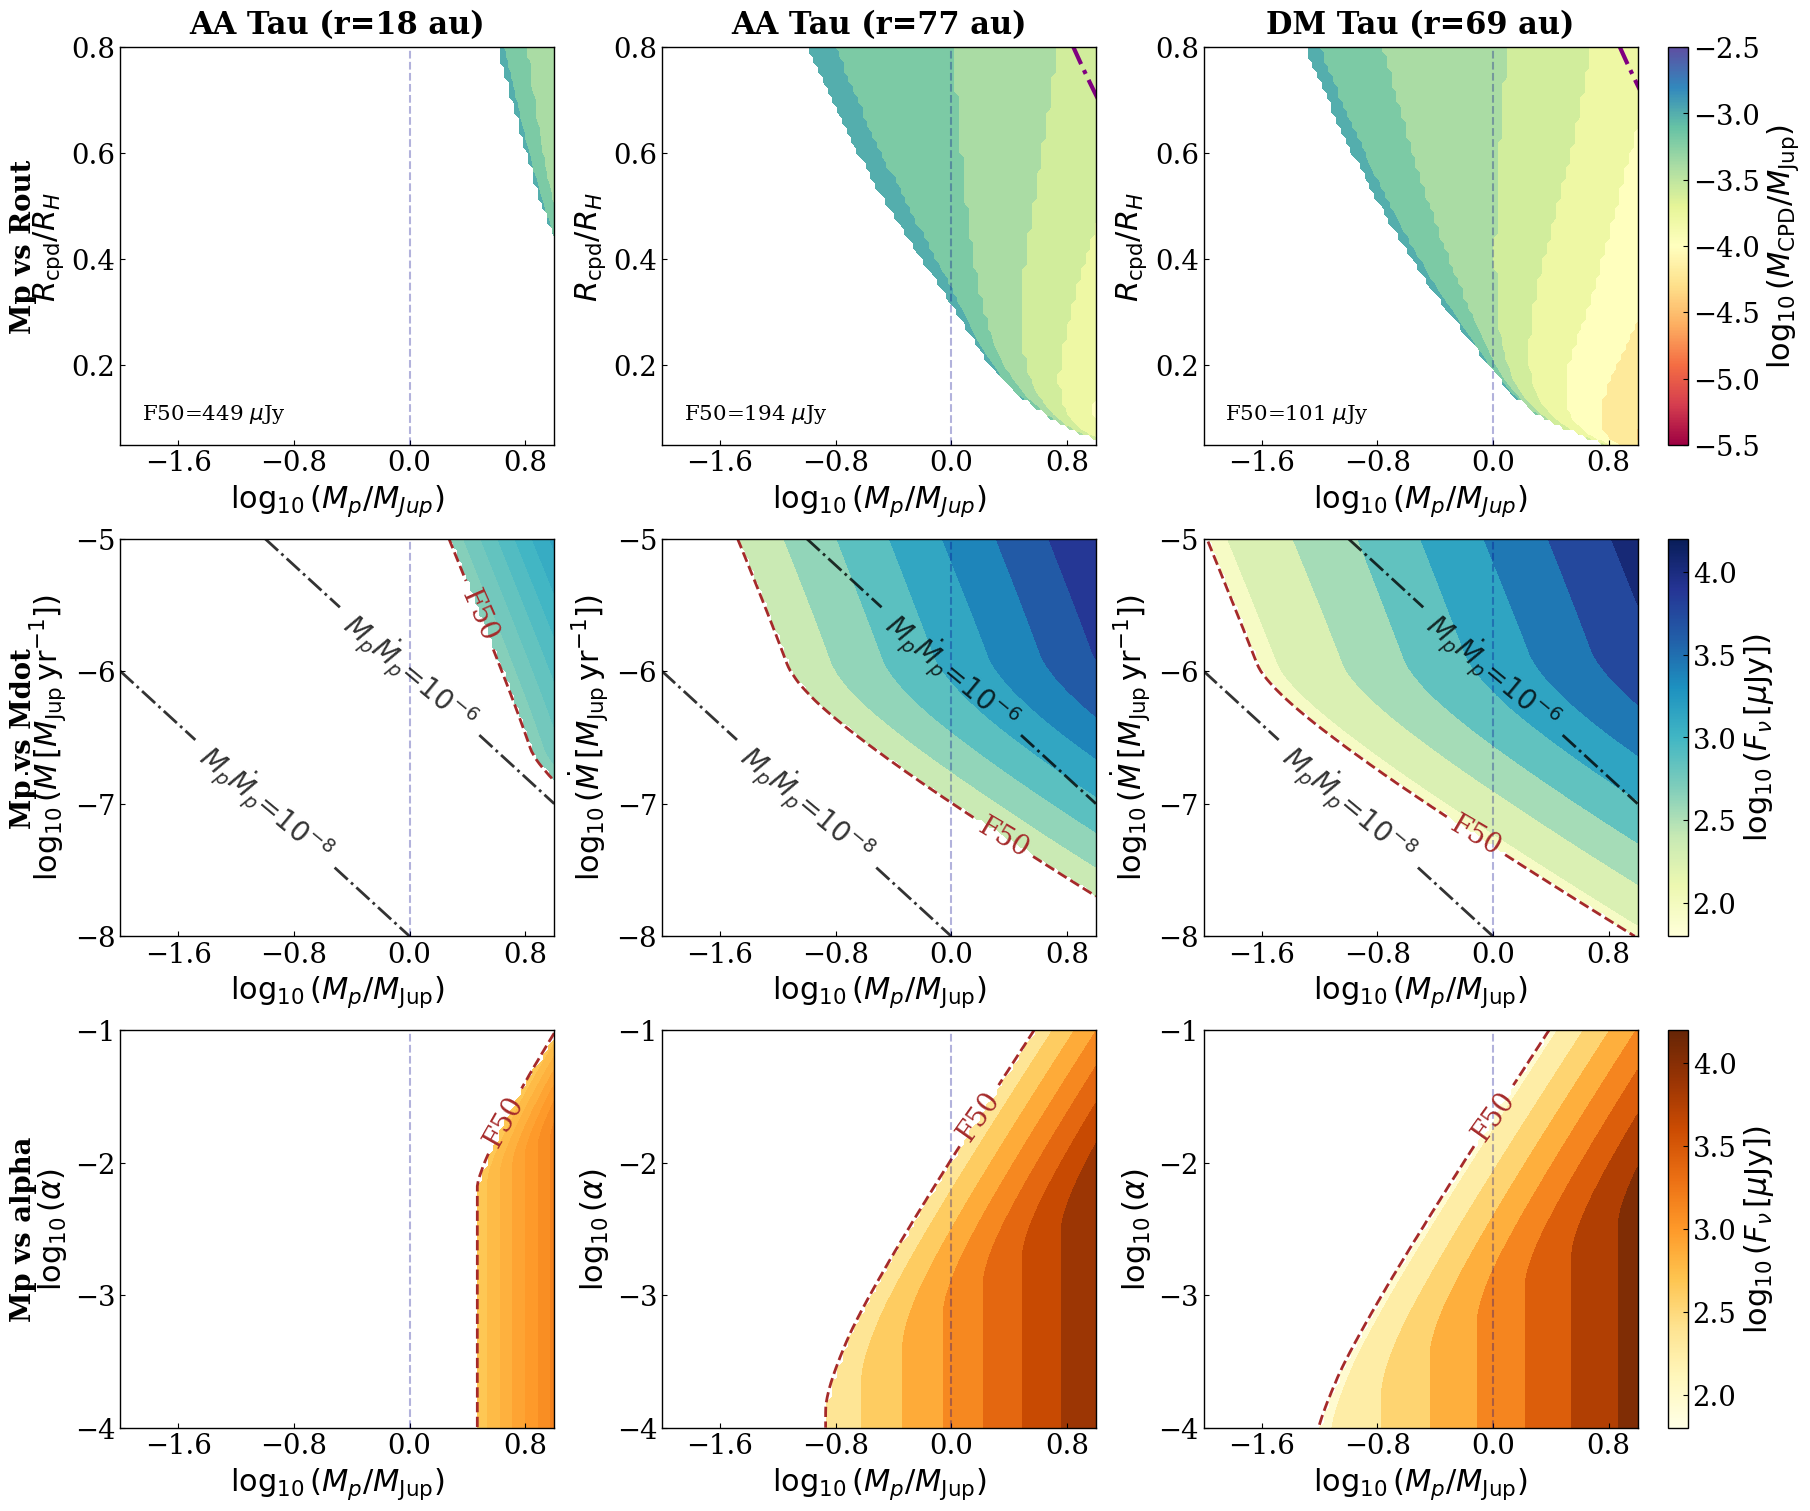

logMp_limit = 4.434917057563535 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 3.470615084272021 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.332381186062188 xlim = (np.float64(-2.0), np.float64(1.0))


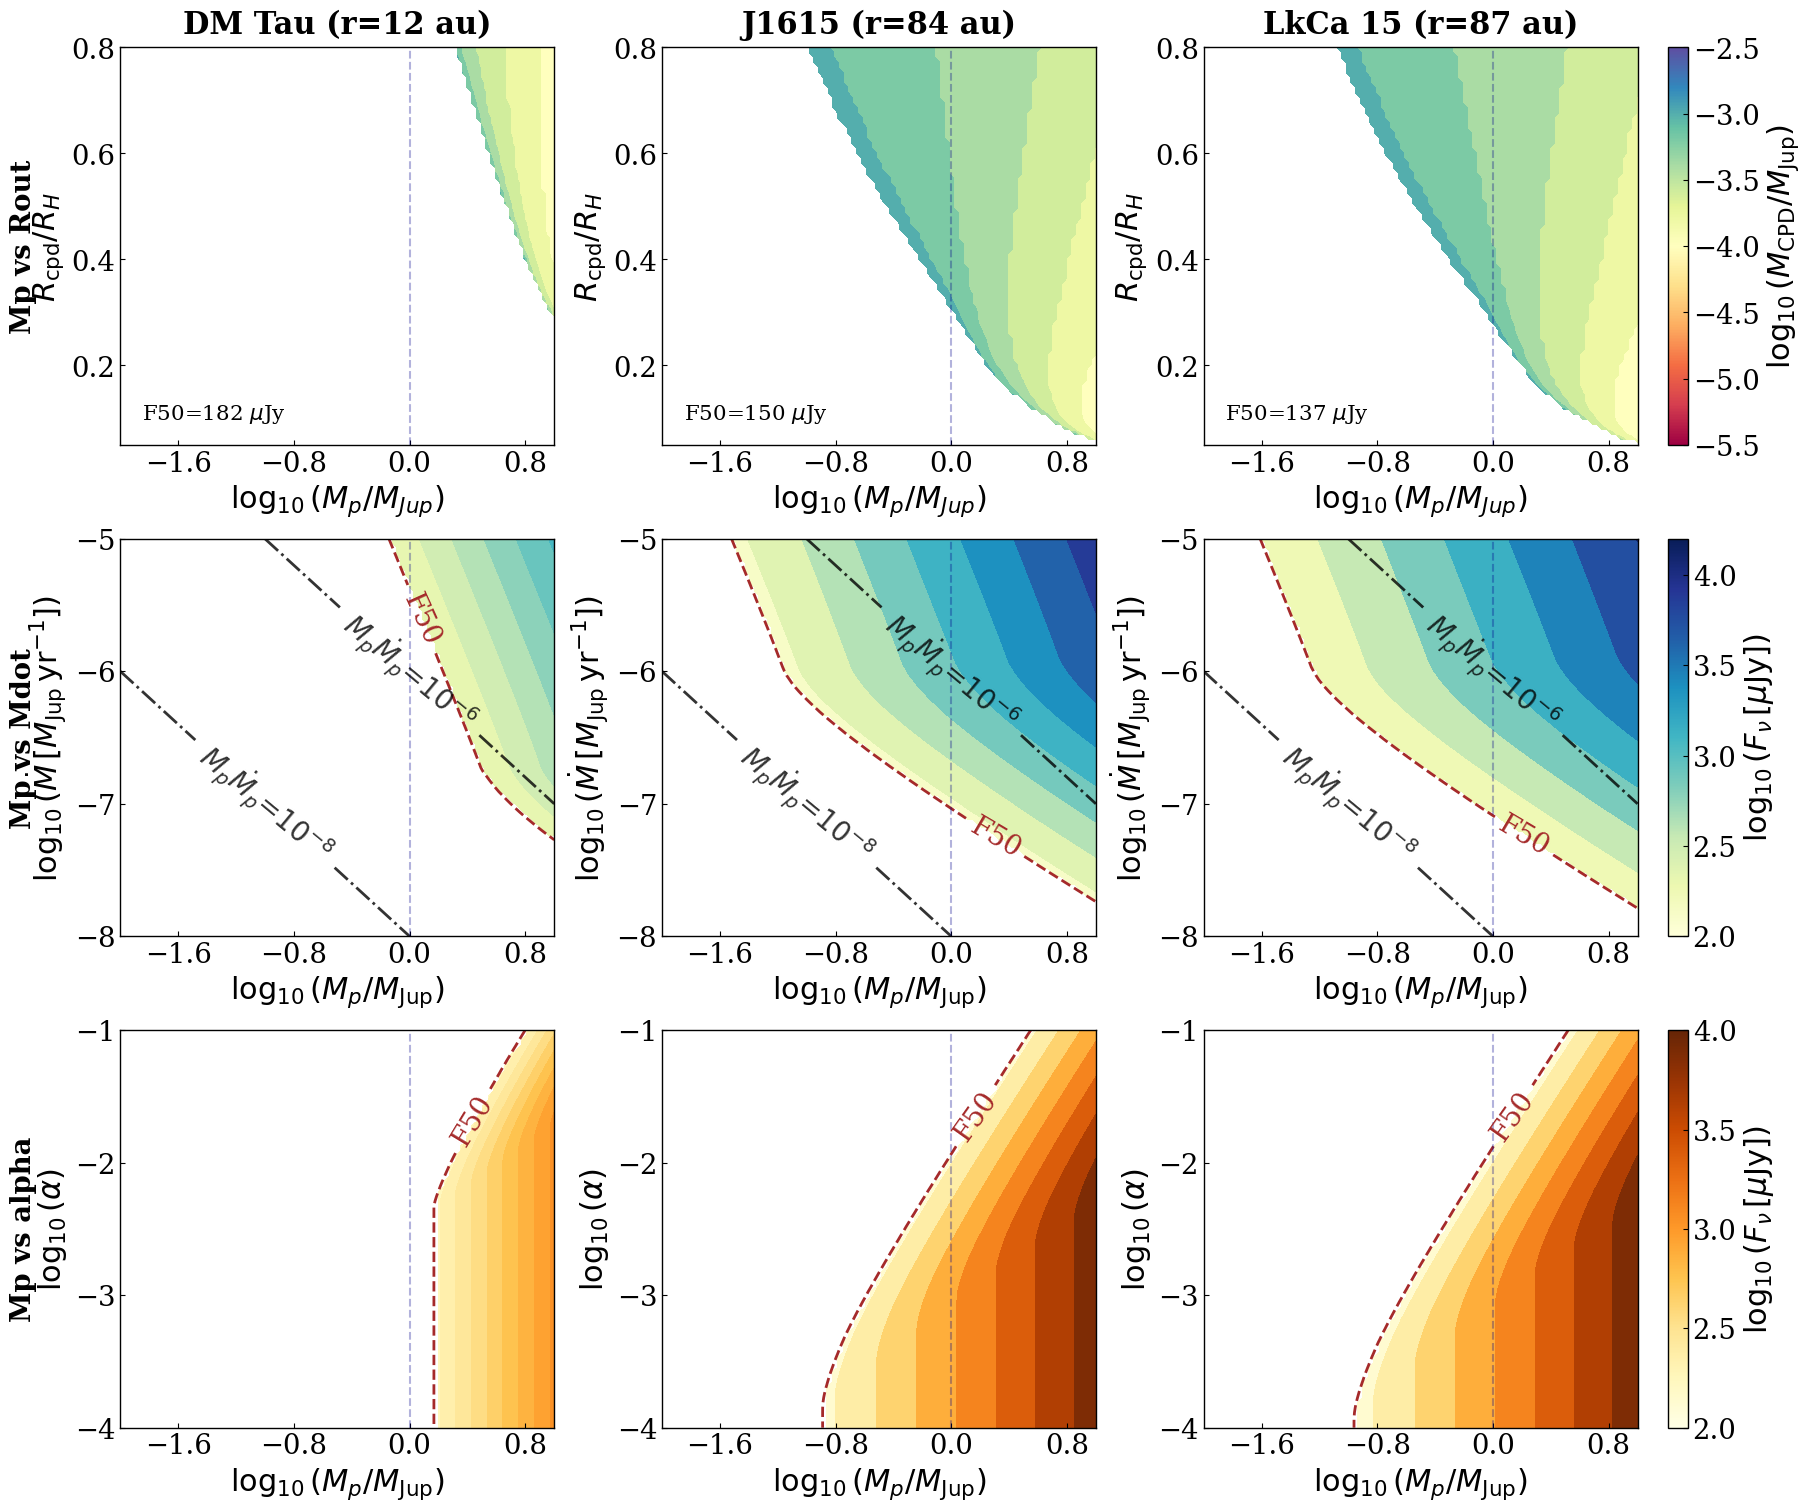

logMp_limit = 5.2882114156000695 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 3.91190380430342 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 4.215851143706156 xlim = (np.float64(-2.0), np.float64(1.0))


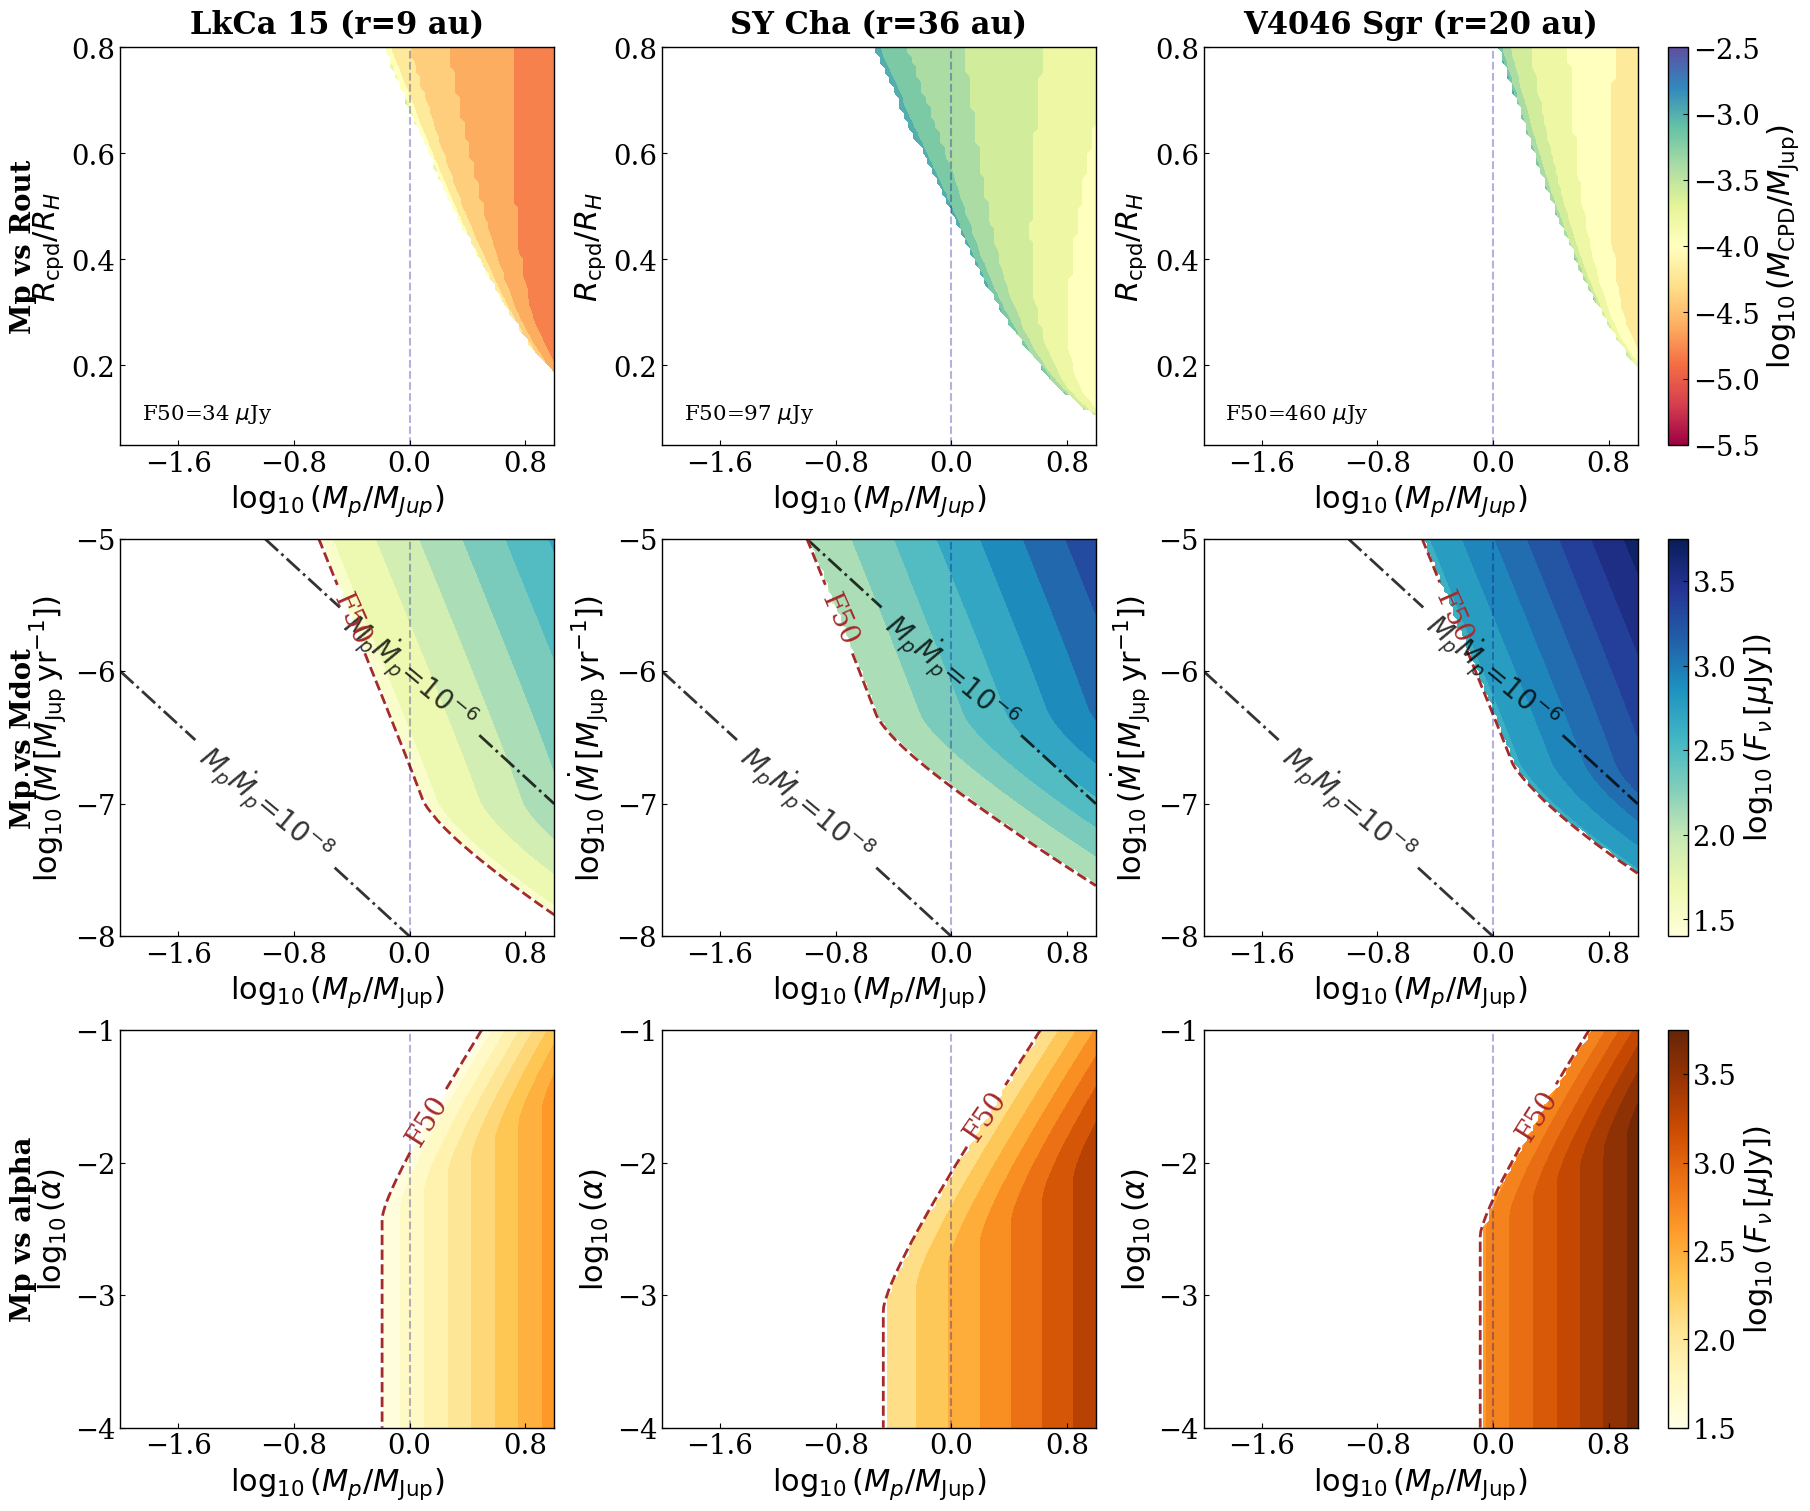

logMp_limit = 5.784487379547168 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 5.885080805800041 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 5.768049897837341 xlim = (np.float64(-2.0), np.float64(1.0))


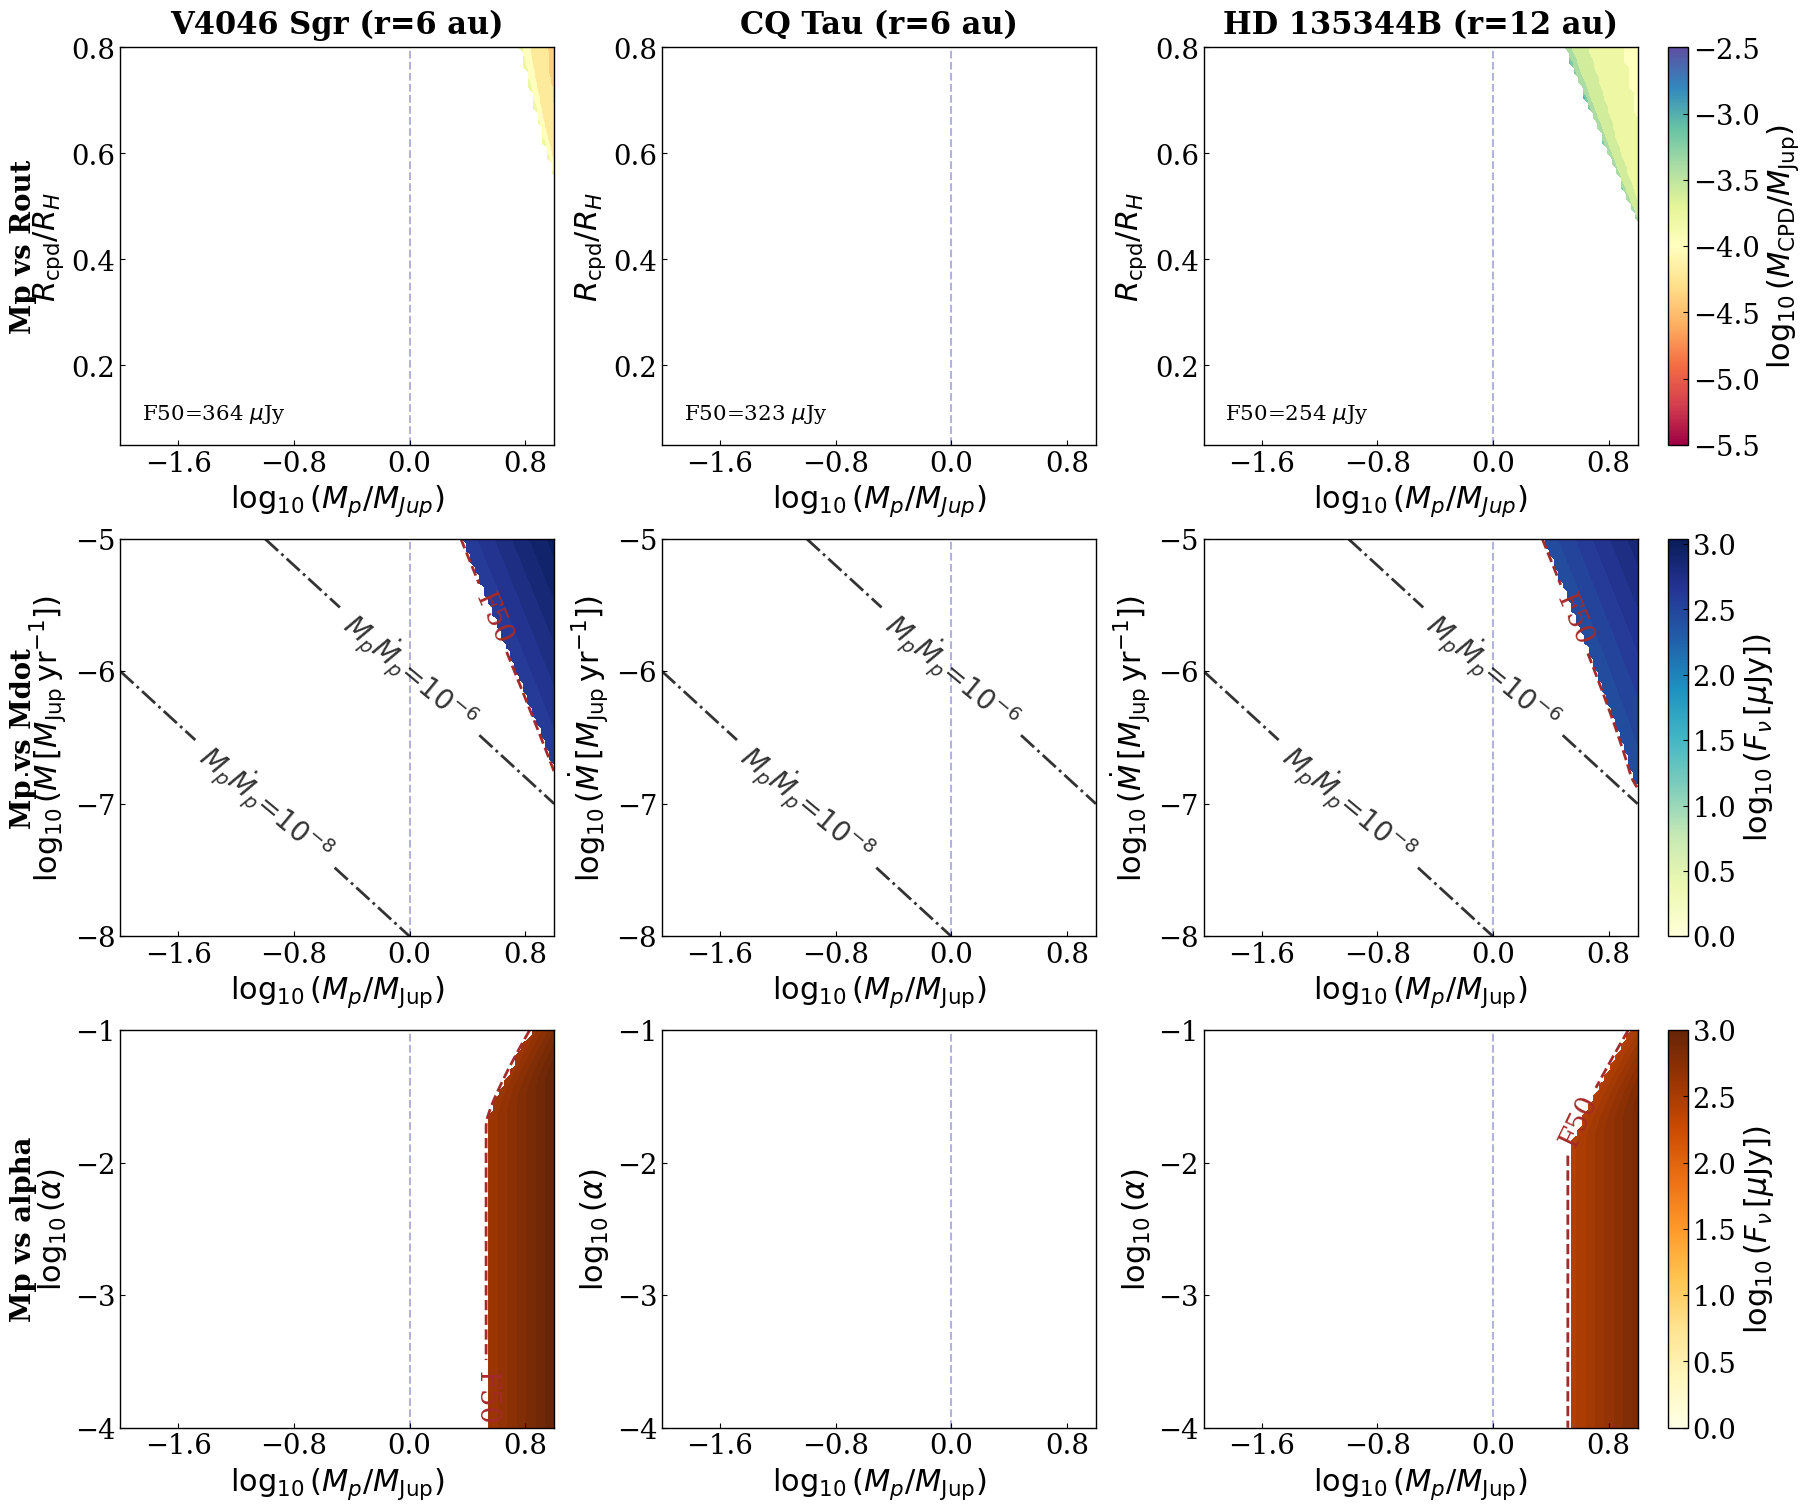

logMp_limit = 3.5028795279501734 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 4.602551622394801 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 5.155695612974758 xlim = (np.float64(-2.0), np.float64(1.0))


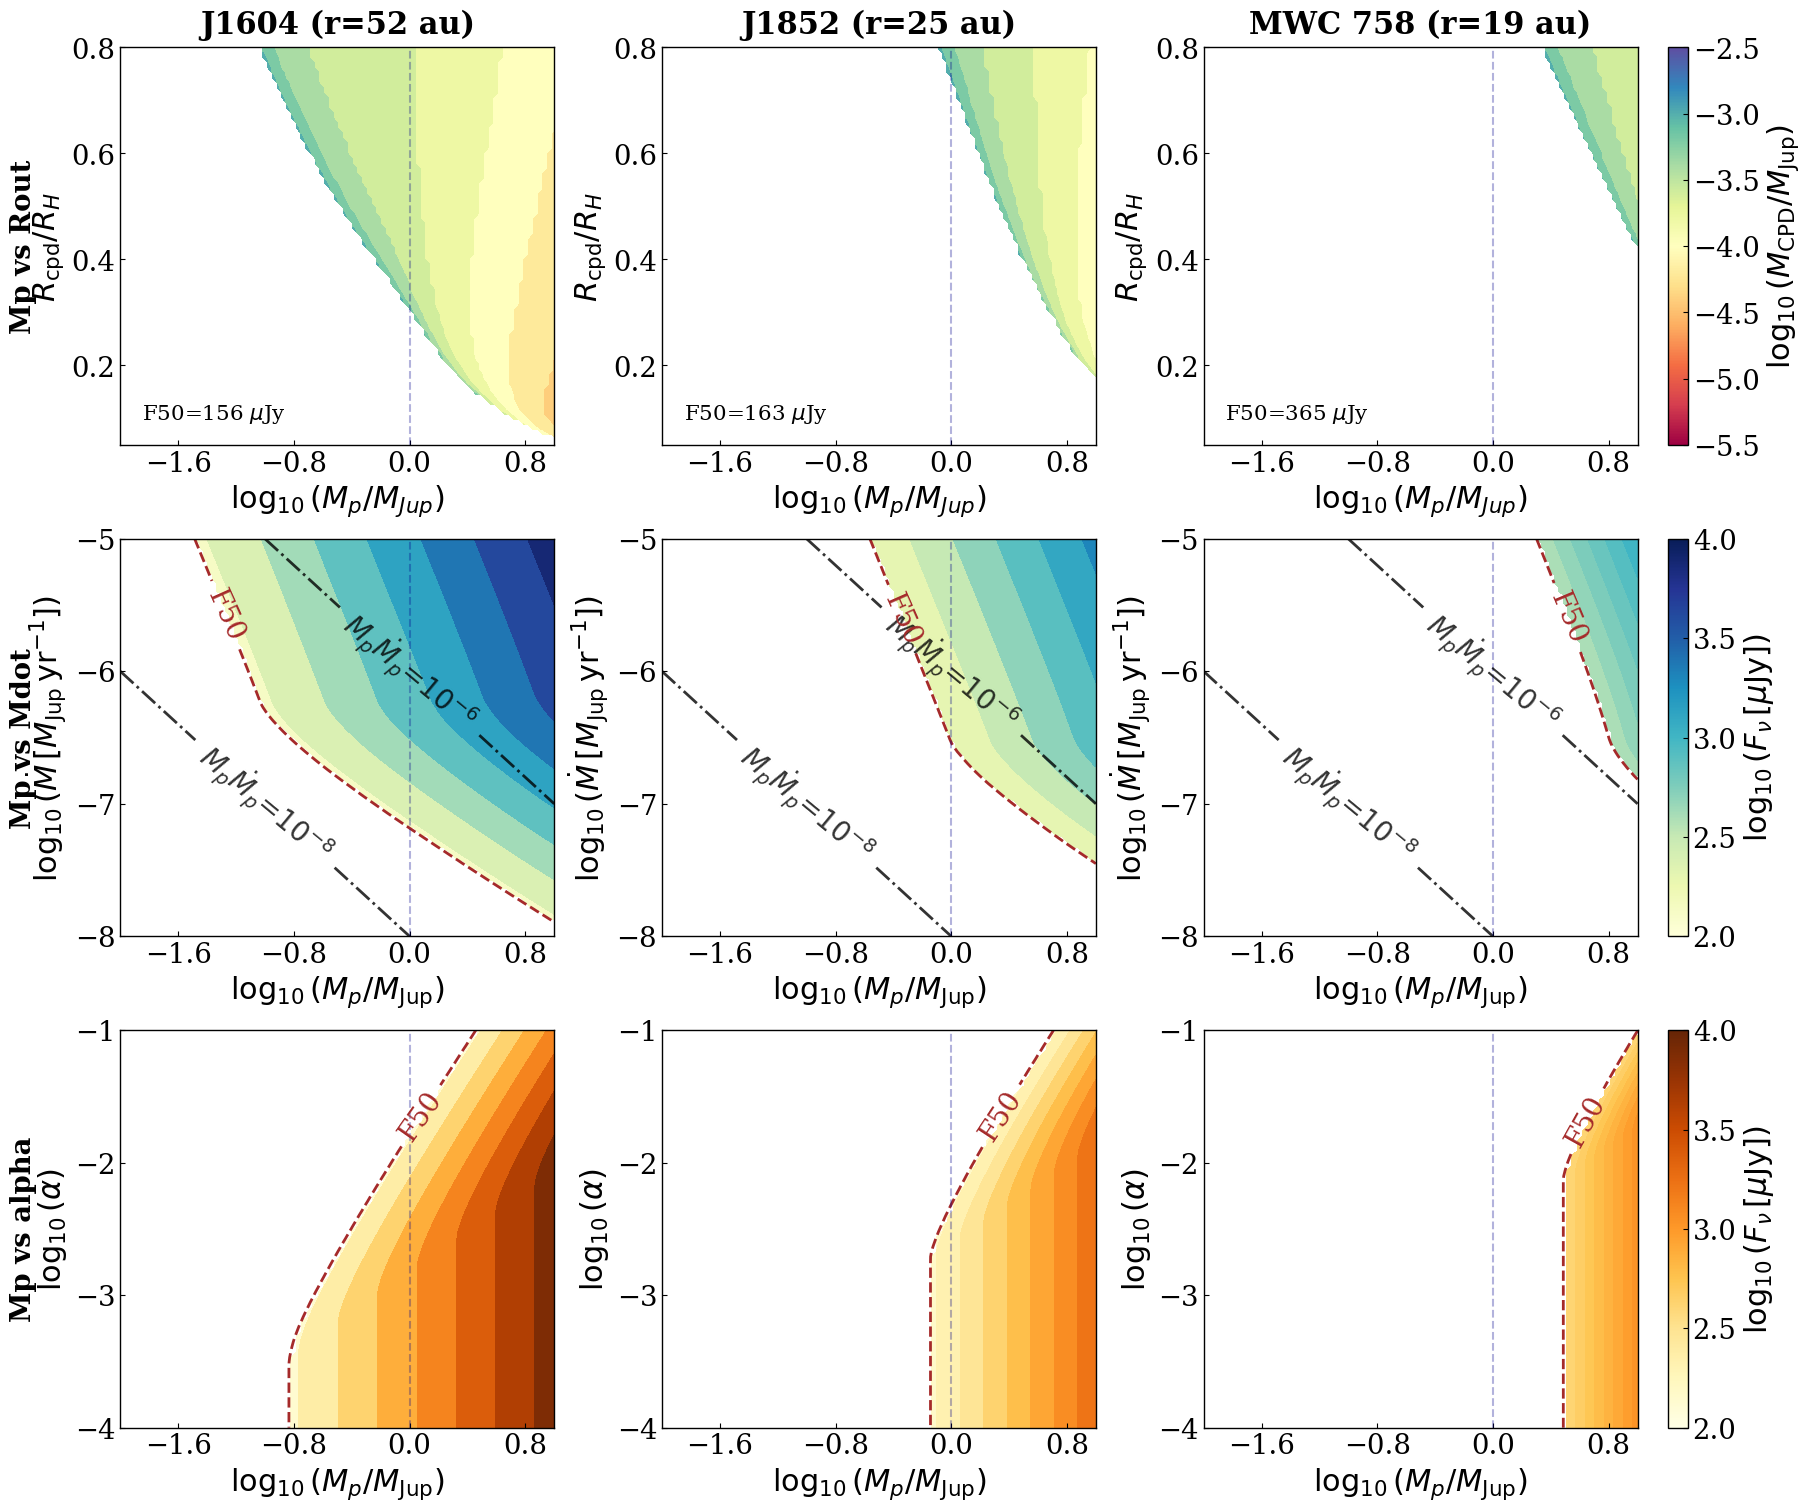

In [4]:
# same 11 targets/15 entries as the curated combined grid in
# injrev_sum_plot.ipynb (drops HD_135344B_gap0 -- never reaches 50% -- and
# J1615_gap1 -- sub-beam), grouped by target in the same order, split into
# 3-column plots
curated_gap_sources = [
    ["AA_Tau",     18, 449.2],
    ["AA_Tau",     77, 194.0],
    ["DM_Tau",     69, 101.0],
    ["DM_Tau",     12, 182.0],
    ["J1615",      84, 150.2],
    ["LkCa_15",    87, 137.0],
    ["LkCa_15",     9,  34.0],
    ["SY_Cha",     36,  97.4],
    ["V4046_Sgr",  20, 459.5],
    ["V4046_Sgr",   6, 364.0],
    ["CQ_Tau",      6, 323.3],
    ["HD_135344B", 12, 253.6],
    ["J1604",      52, 156.3],
    ["J1852",      25, 163.3],
    ["MWC_758",    19, 365.1],
]
curated_boundary_au = {**gap_boundary_au, **cavity_boundary_au}

for start in range(0, len(curated_gap_sources), 3):
    plot_emission_grid(curated_gap_sources[start:start + 3], mode="gap_curated",
                        gap_boundary_au=curated_boundary_au)

In [5]:
# diagnostic: gap/cavity width vs. the biggest possible CPD size (0.8*R_Hill
# at the plot's Mp upper edge, 10 Mjup) -- explains why the R_cpd>gap-width
# hatch (Andrew_model.plot_flux_map's gap_boundary_au, hatch='xx') never shows
# up in row 1: the gap is always many times wider than any planetary-mass CPD
# could ever be, so the exclusion zone sits entirely off the plotted x-range.
Mp_ref = 10  # Mjup, andrews_x_max default (10**1)
print(f"{'disk_r':<20}{'gap width (au)':>16}{'max CPD size (au)':>20}{'gap / max CPD':>16}")
for (name, r_au), gap_w_au in curated_boundary_au.items():
    M_star_jup = disk_arr[name][1] * 1047.56
    RHill = r_au * (Mp_ref / (3 * M_star_jup)) ** (1 / 3)
    R_cpd_max = 0.8 * RHill
    print(f"{name + '_r' + str(r_au):<20}{gap_w_au:16.2f}{R_cpd_max:20.3f}{gap_w_au / R_cpd_max:16.1f}")

disk_r                gap width (au)   max CPD size (au)   gap / max CPD
AA_Tau_r18                     12.11               2.291             5.3
AA_Tau_r77                     32.78               9.801             3.3
DM_Tau_r69                     14.46              10.595             1.4
J1615_r84                      17.14               9.462             1.8
LkCa_15_r87                    11.35               9.800             1.2
SY_Cha_r36                     23.63               4.622             5.1
V4046_Sgr_r20                   5.30               1.960             2.7
CQ_Tau_r6                      16.40               0.631            26.0
DM_Tau_r12                      8.20               1.843             4.4
HD_135344B_r12                 21.33               1.205            17.7
J1604_r52                      15.99               5.621             2.8
J1852_r25                      12.62               2.913             4.3
LkCa_15_r9                     18.83               

In [6]:
# summary table across all 15 curated Gap+Inner_cavity columns -- for the paper,
# this replaces writing one paragraph per disk. Reuses the already-cached grids
# (mode="gap_curated"), no new model calls. Columns:
#   Mp_floor       -- row 1 (Andrews, default alpha=1e-3/Mdot=1.56 Mjup/Myr):
#                     smallest Mp for which ANY (Rout/RH, Mcpd) reaches F50
#   Mp2_best/worst -- row 2 (Zhu, Mp vs Mdot @ alpha=1e-3): smallest Mp reaching
#                     F50 at the most/least favorable accretion rate searched
#   Mp3_best/worst -- row 3 (Zhu, Mp vs alpha @ Mdot=Mp/1e6): same, across the
#                     most/least favorable viscosity searched
#   regime         -- heating- vs Sigma-dominated (see heating_vs_sigma_slope)
#                     at the fiducial alpha=1e-3 F50 crossing
rows = []
for disk_name, disk_radius, sigma_ujy in curated_gap_sources:
    Mp1, _, Flux1, _ = get_andrews_grid(disk_name, disk_radius, sigma_ujy, "gap_curated", alpha=1e-3)
    reach1 = np.any(Flux1 >= sigma_ujy, axis=0)
    mp_floor = Mp1[reach1].min() if reach1.any() else np.nan

    Mp2, _, Flux2, _ = get_zhu_mpmdot_grid(disk_name, disk_radius, "gap_curated", alpha=1e-3)
    reach2_best, reach2_worst = Flux2[-1, :] >= sigma_ujy, Flux2[0, :] >= sigma_ujy
    mp2_best = Mp2[reach2_best].min() if reach2_best.any() else np.nan
    mp2_worst = Mp2[reach2_worst].min() if reach2_worst.any() else np.nan

    Mp3, alpha3, Flux3, _ = get_zhu_mpalpha_grid(disk_name, disk_radius, "gap_curated")
    reach3_best, reach3_worst = Flux3[0, :] >= sigma_ujy, Flux3[-1, :] >= sigma_ujy
    mp3_best = Mp3[reach3_best].min() if reach3_best.any() else np.nan
    mp3_worst = Mp3[reach3_worst].min() if reach3_worst.any() else np.nan

    slope3 = heating_vs_sigma_slope(alpha3, Flux3)
    j_fid = np.argmin(np.abs(alpha3 - 1e-3))
    reach_fid = Flux3[j_fid, :] >= sigma_ujy
    regime = "n/a"
    if reach_fid.any():
        mp_ix = np.argmax(reach_fid)
        regime = "heating" if slope3[j_fid, mp_ix] > -0.5 else "Sigma"

    rows.append([disk_name, disk_radius, sigma_ujy, mp_floor, mp2_best, mp2_worst, mp3_best, mp3_worst, regime])

summary_df = pd.DataFrame(rows, columns=["disk", "r_au", "F50_ujy", "Mp_floor",
                                          "Mp2_best", "Mp2_worst", "Mp3_best", "Mp3_worst", "regime"])
summary_df

,disk,r_au,F50_ujy,Mp_floor,Mp2_best,Mp2_worst,Mp3_best,Mp3_worst,regime
0,AA_Tau,18,449.2,4.229243,1.873817,NaN,2.940048,NaN,heating
1,AA_Tau,77,194.0,0.104154,0.035112,NaN,0.137797,3.821893,Sigma
2,DM_Tau,69,101.0,0.052750,0.010723,10.0,0.062729,2.468340,Sigma
3,DM_Tau,12,182.0,2.141944,0.756463,NaN,1.594159,6.458424,heating
4,J1615,84,150.2,0.104154,0.030539,NaN,0.137797,3.821893,Sigma
5,LkCa_15,87,137.0,0.083022,0.024771,NaN,0.115689,3.501900,Sigma
6,LkCa_15,9,34.0,0.689261,0.247708,NaN,0.664944,3.208700,heating
7,SY_Cha,36,97.4,0.300105,0.107227,NaN,0.360547,4.171125,heating
8,V4046_Sgr,20,459.5,1.084810,0.327455,NaN,0.864388,4.968240,heating
9,V4046_Sgr,6,364.0,5.722368,2.310130,NaN,3.501900,7.048574,heating


## Paper figure groupings

Same 11 sources as the curated grid above, regrouped to match the paper's 4
constraint categories instead of the arbitrary batches-of-3 split. Reuses the
`gap_curated` cache -- no new model calls.

Geometry-limited systems


D:\CPD_MPIA\CPD_Emission_Models\Andrew_model.py:369: RuntimeWarning: divide by zero encountered in log10
  np.log10(M_cpd_chosen),


logMp_limit = 5.885080805800041 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 5.784487379547168 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 5.768049897837341 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 4.016303731379216 xlim = (np.float64(-2.0), np.float64(1.0))


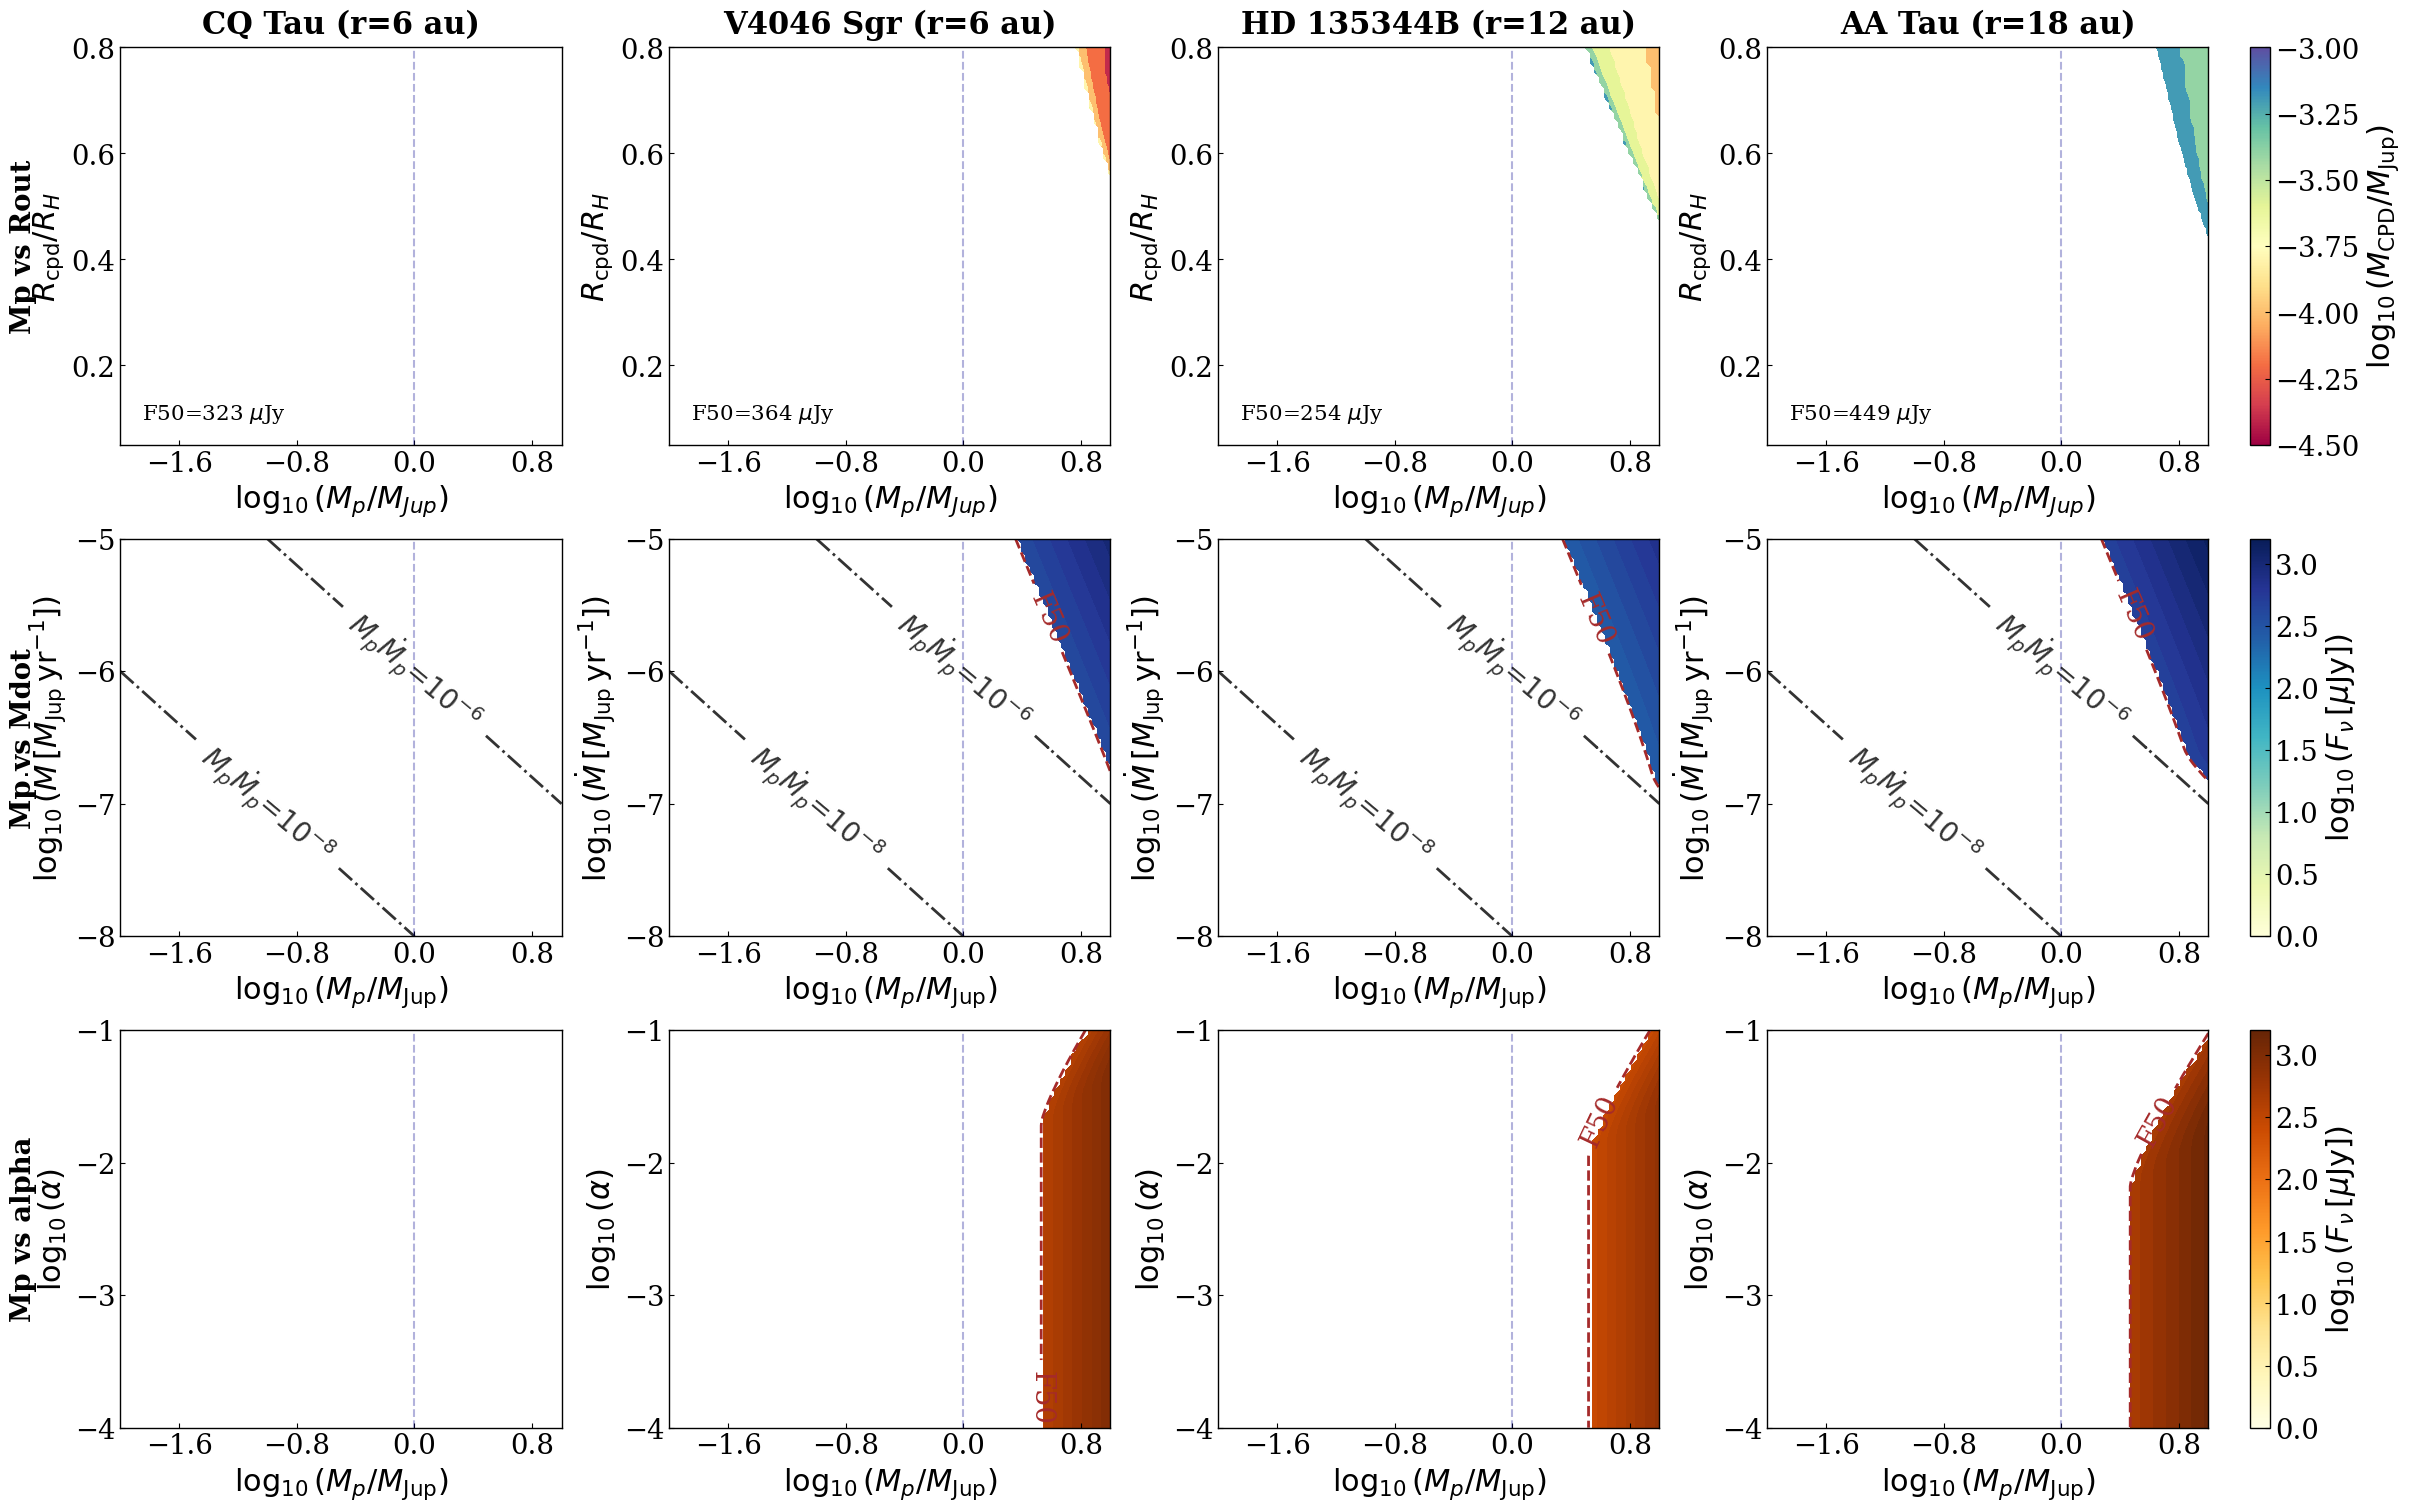

Robust / favourable-geometry constraints
logMp_limit = 4.434917057563535 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 4.215851143706156 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 5.2882114156000695 xlim = (np.float64(-2.0), np.float64(1.0))


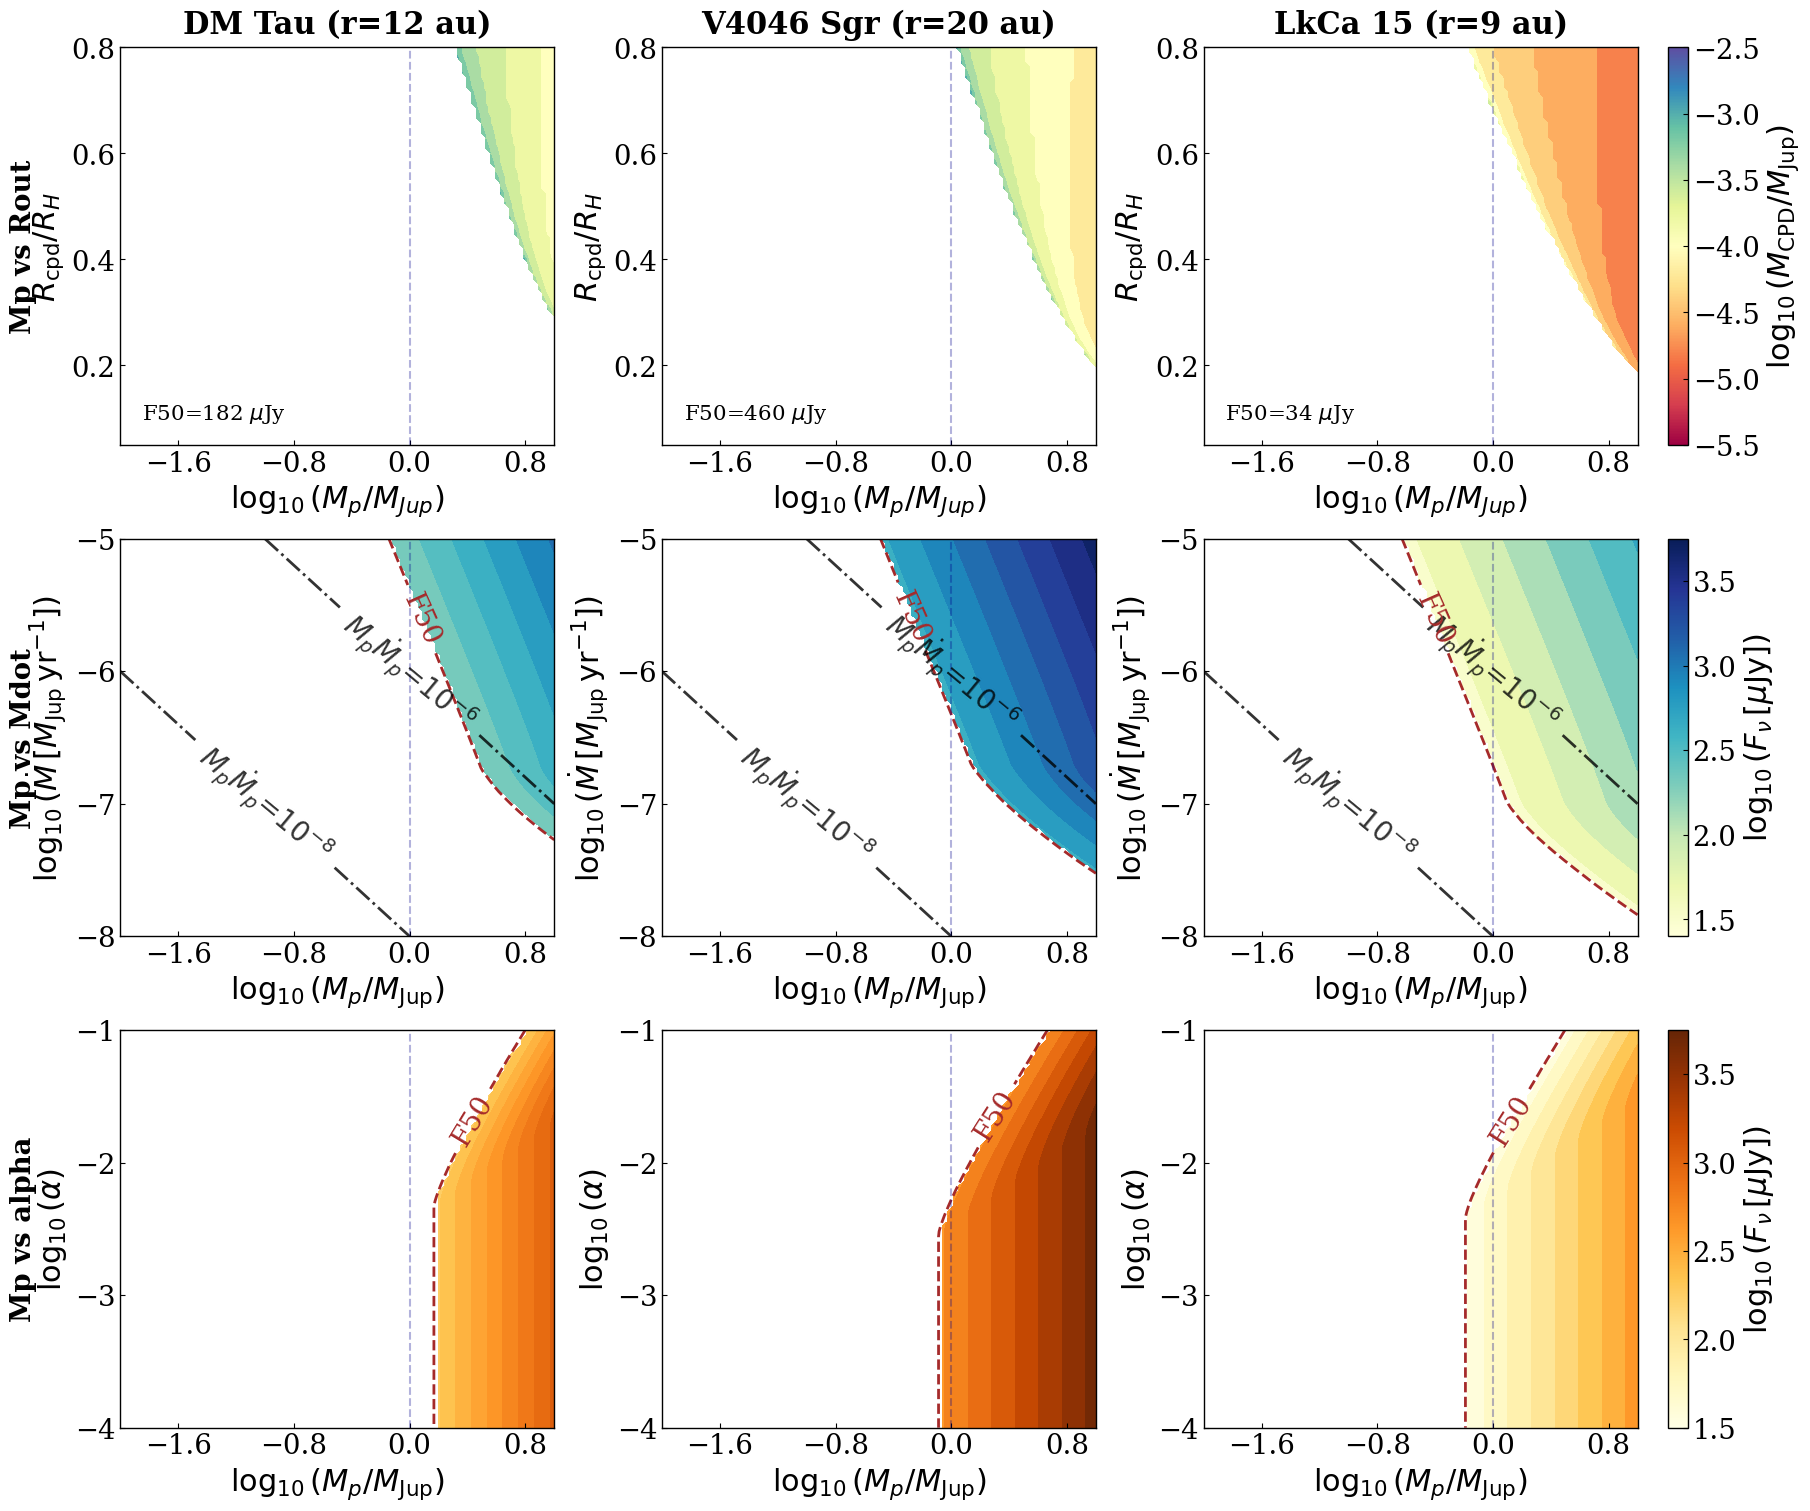

Strong but model-dependent constraints
logMp_limit = 3.5028795279501734 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 3.470615084272021 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.332381186062188 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 3.91190380430342 xlim = (np.float64(-2.0), np.float64(1.0))


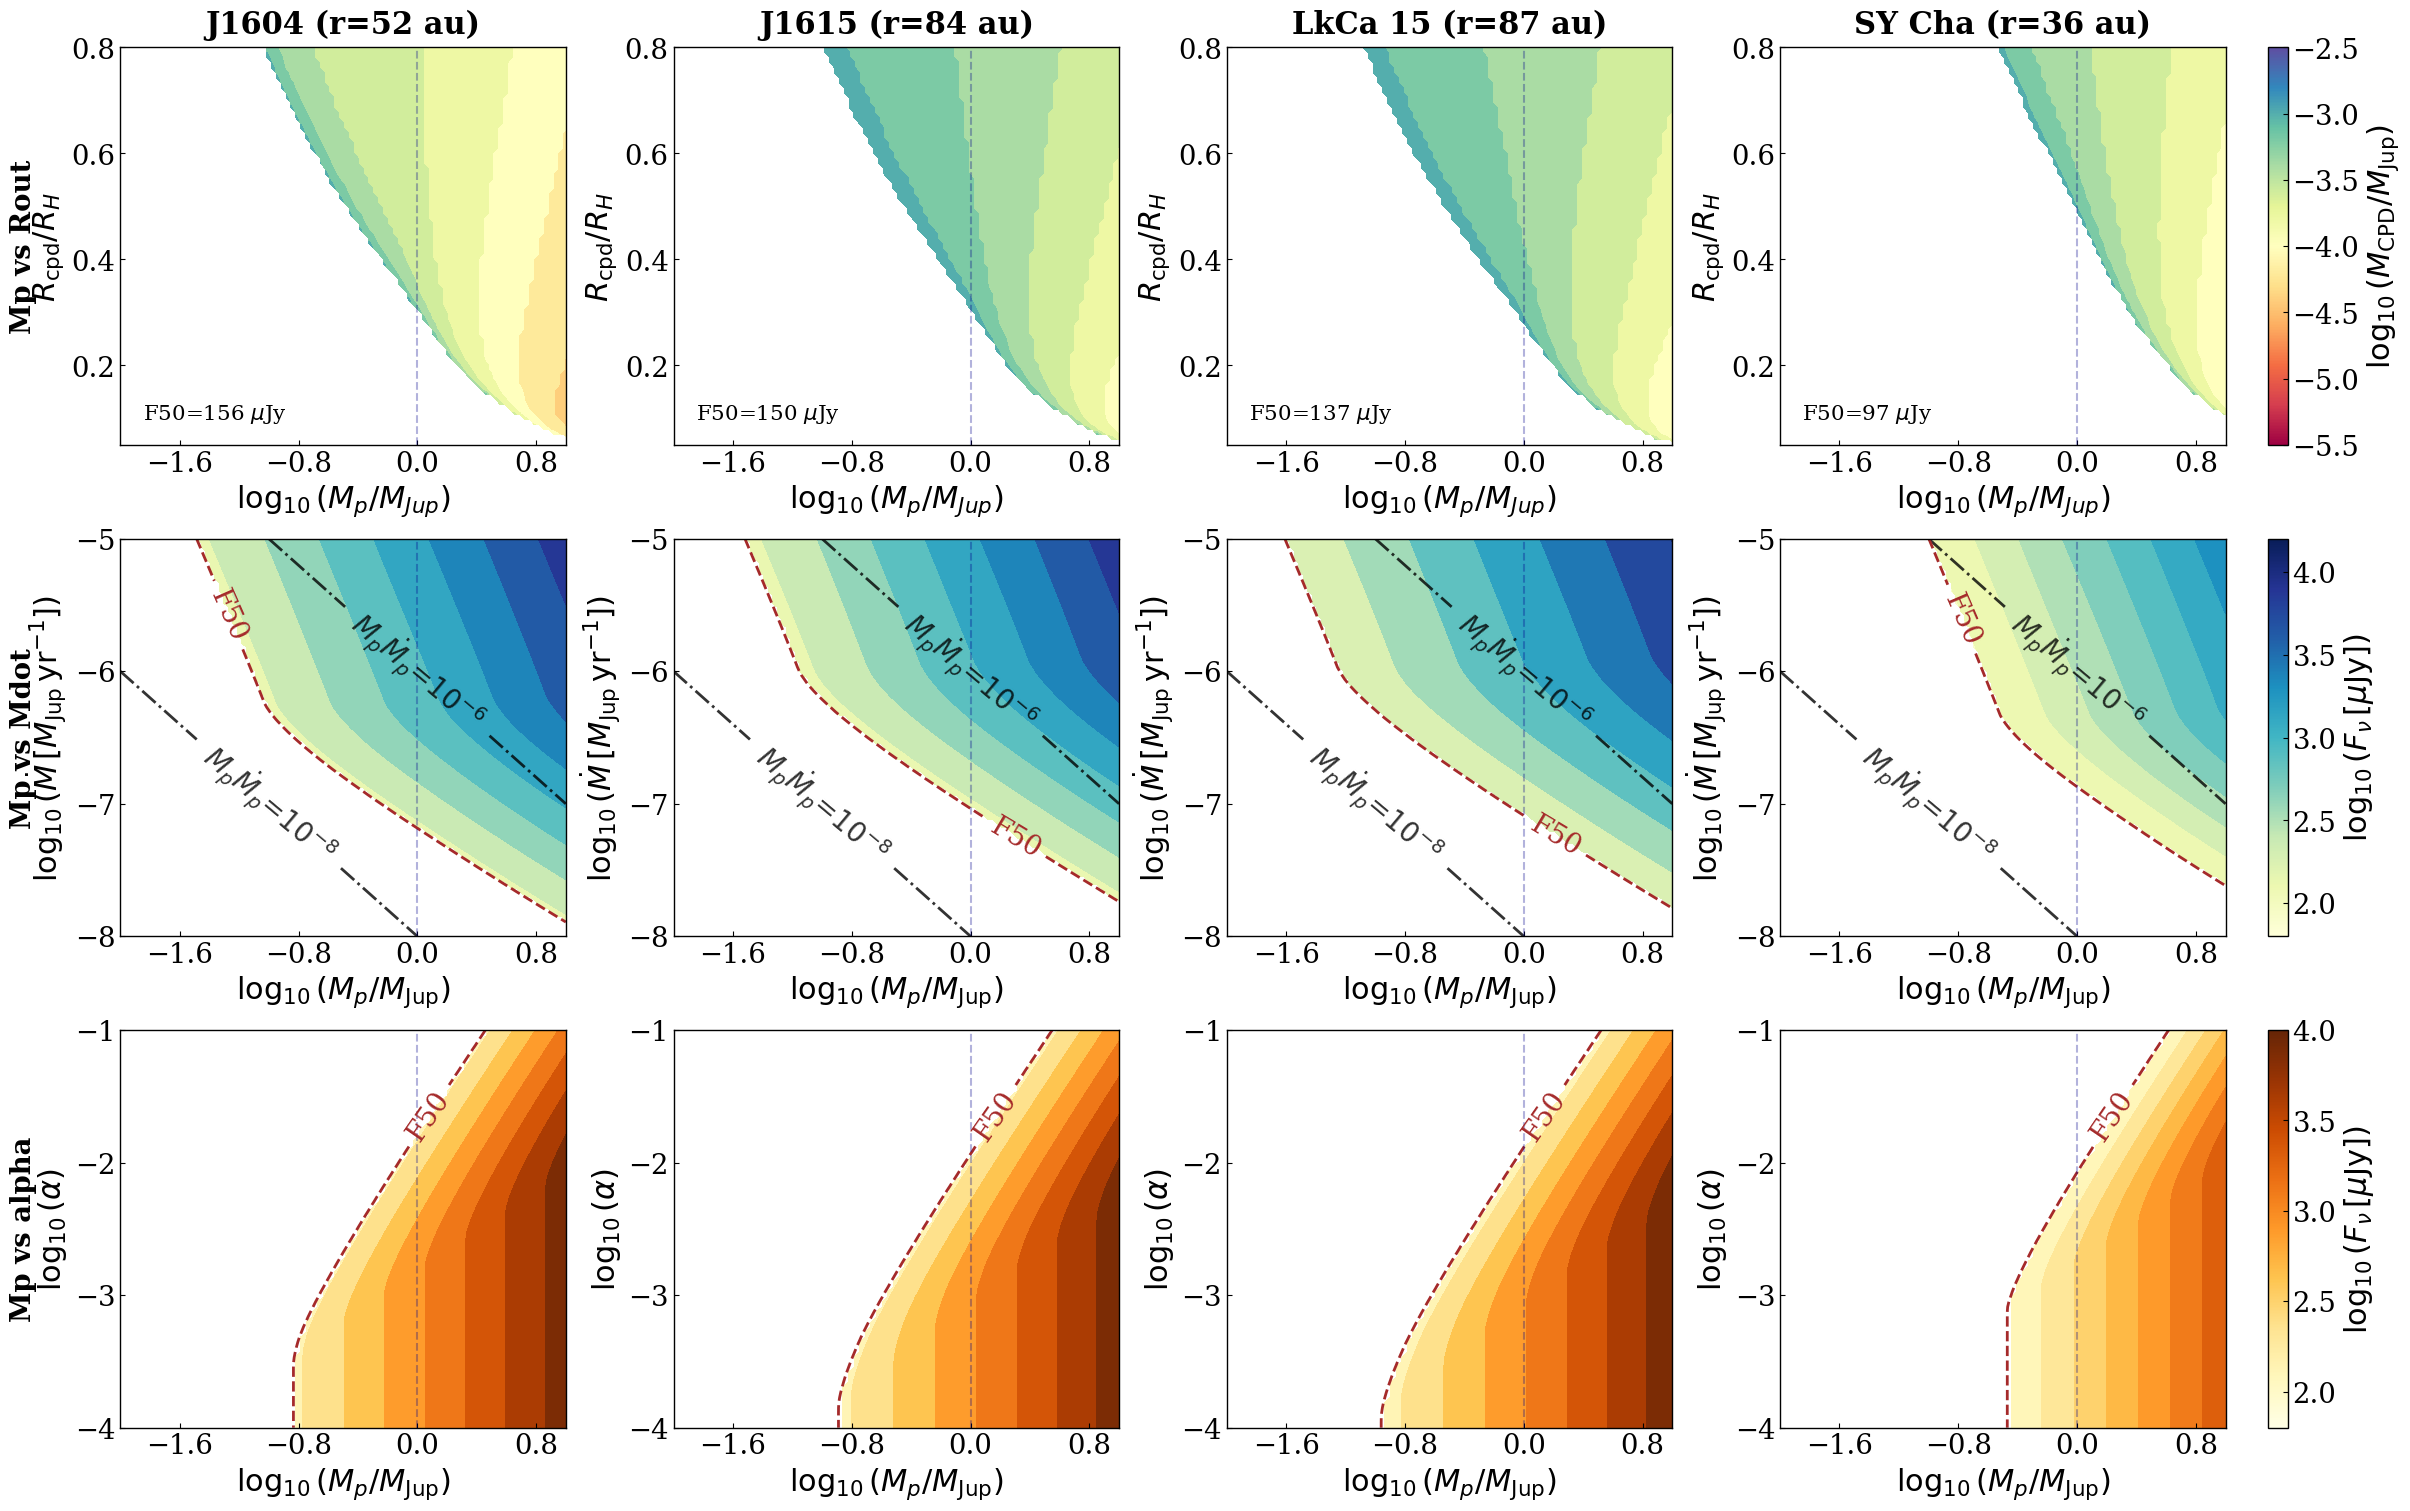

In [7]:
# Format: [disk_name, radius_au, F50_ujy] -- same entries as curated_gap_sources
geometry_limited = [
    ["CQ_Tau",      6, 323.3],
    ["V4046_Sgr",   6, 364.0],
    ["HD_135344B", 12, 253.6],
    ["AA_Tau",     18, 449.2],
]
robust_and_favourable_geometry = [
    ["DM_Tau",     12, 182.0],
    ["V4046_Sgr",  20, 459.5],
    ["LkCa_15",     9,  34.0],
]
strong_but_model_dependent = [
    ["J1604",      52, 156.3],
    ["J1615",      84, 150.2],
    ["LkCa_15",    87, 137.0],
    ["SY_Cha",     36,  97.4],
]

for title, sources, cmin, cmax in [
    # geometry_limited's actual M_cpd range is only ~-4.5 to -3.0 -- the
    # default -5.5/-2.5 (calibrated for the full 15-disk set) wastes most of
    # the colorbar and compresses the real contrast for this small subgroup
    ("Geometry-limited systems", geometry_limited, -4.5, -3.0),
    ("Robust / favourable-geometry constraints", robust_and_favourable_geometry, -5.5, -2.5),
    ("Strong but model-dependent constraints", strong_but_model_dependent, -5.5, -2.5),
]:
    print(title)
    plot_emission_grid(sources, mode="gap_curated", gap_boundary_au=curated_boundary_au,
                        andrews_cmin=cmin, andrews_cmax=cmax)

## HD_135344B point candidates (C1, C2, DF)

These aren't detection limits -- injection recovery showed all three sit on a real, persistent source (recovery is ~100% from the lowest tested flux, at a fixed sky position, regardless of injected flux). So instead of a meaningless F50, this uses the actual measured persistent flux at each candidate's position (from the raw `*_recoveries.combined.txt`, the near-constant recovered flux at the lowest injected bin) as the target flux fed into the emission models -- i.e. "what CPD parameters would explain this real detected flux."

logMp_limit = 4.167242065821009 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 3.1001447903184105 xlim = (np.float64(-2.0), np.float64(1.0))


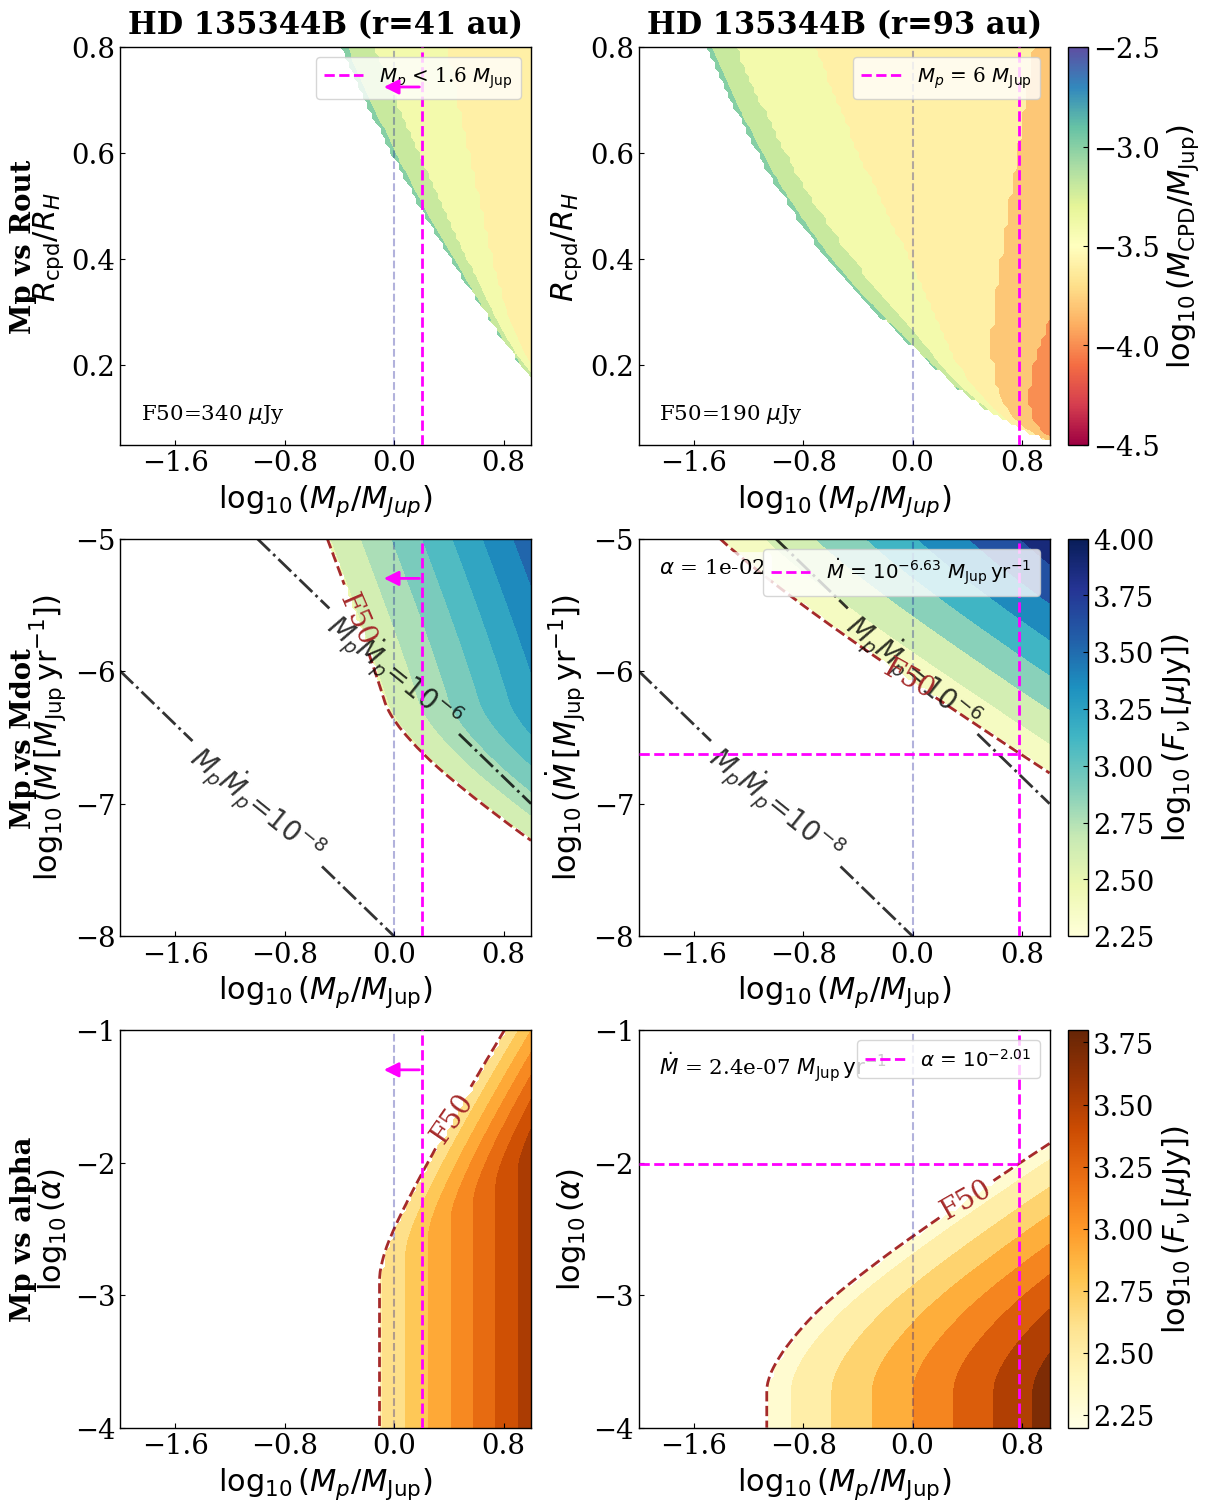

In [8]:
# HD_135344B candidates -- persistent measured flux (not F50), see markdown above
# Format: [disk_name, radius_au, flux_ujy]
candidate_sources = [
    ["HD_135344B", 41,  340.0],   # C1: R=0.30"
    ["HD_135344B", 93,  190.0],   # DF: R=0.69" -- C2 (73 au) excluded
]

# gap-boundary hatch: no wgap for a point candidate, so use the injection
# zone's own radial half-width instead (+/-1 beam, same as injrev_sum_plot.ipynb)
BEAM_FWHM = 0.0786   # arcsec, robust=-0.5 beam used to size the injection zone
inj_zone_boundary_au = BEAM_FWHM * disk_arr["HD_135344B"][2]
candidate_boundary_au = {(name, r_au): inj_zone_boundary_au for name, r_au, _ in candidate_sources}

# C1: no mass estimate -- upper limit only (Mp < 1.6 Mjup), shown as a
# magenta dashed line + left-pointing arrow instead of a fixed-value line.
# DF (doppler flip): planet mass estimate of 6 Mjup, plus a higher viscosity
# (alpha=1e-2 instead of the 1e-3 used everywhere else) for its row-2 (Mp vs
# Mdot) panel only -- annotated on that panel so the change is visible.
candidate_mass_upper_limits = {("HD_135344B", 41): 1.6}
candidate_planet_masses = {("HD_135344B", 93): 6}
candidate_zhu2_alpha_by_col = {("HD_135344B", 93): 1e-2}

# row 3 (Mp vs alpha) for DF: instead of the default Mdot=Mp/1e6 scaling,
# hold Mdot fixed at the row-2 (Mp=6 Mjup) x F50 intersection value
df_disk, df_radius, df_flux = "HD_135344B", 93, 190.0
Mp_grid2_df, Mdot_grid_df, Flux_vals2_df, _ = get_zhu_mpmdot_grid(
    df_disk, df_radius, "candidate", alpha=candidate_zhu2_alpha_by_col[(df_disk, df_radius)],
)
j2_df = np.argmin(np.abs(np.log10(Mp_grid2_df) - np.log10(6)))
order2_df = np.argsort(Flux_vals2_df[:, j2_df])
logmdot_F50_df = np.interp(np.log10(df_flux), np.log10(Flux_vals2_df[:, j2_df][order2_df]), np.log10(Mdot_grid_df[order2_df]))
candidate_zhu3_mdot_by_col = {(df_disk, df_radius): 10 ** logmdot_F50_df}

plot_emission_grid(
    candidate_sources, mode="candidate", gap_boundary_au=candidate_boundary_au,
    andrews_cmin=-4.5, andrews_cmax=-2.5,
    mass_upper_limits=candidate_mass_upper_limits,
    planet_masses=candidate_planet_masses,
    zhu2_alpha_by_col=candidate_zhu2_alpha_by_col,
    zhu3_mdot_by_col=candidate_zhu3_mdot_by_col,
)

## Kink candidates

From this session's `HPC_kink` injection-recovery pipeline (F50, criterion B) -- NOT the stale `Dictionaries.kink_sources` entries (different radii/fluxes from an older search). `AA_Tau`, `SY_Cha`, `J1615`, `LkCa_15` still have reps pending; update these once they land.

In [9]:
# Format: [disk_name, radius_au, F50_ujy]
kink_sources_new = [
    ["AA_Tau",   54,  301.0],
    ["SY_Cha",  130,  109.0],
    ["J1615",   165,  107.1],
    ["LkCa_15", 111,  115.6],
    ["J1842",    90,  261.2],
]

# hydro-sim (phantom+mcfost) planet mass estimates, Table 2 -- NOTE: fit at a
# different radius (CO kinematic kink) than our dust-continuum kink position
# for J1615/LkCa_15 in particular; see kink.ipynb re-inspection cell
kink_planet_mass_mjup = {
    "AA_Tau":   2,
    "SY_Cha":   5,
    "J1842":    1,
    "J1615":    2,
    "LkCa_15":  5,
}

logMp_limit = 2.5849399672202287 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.2389812496847714 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.979637088612846 xlim = (np.float64(-2.0), np.float64(1.0))


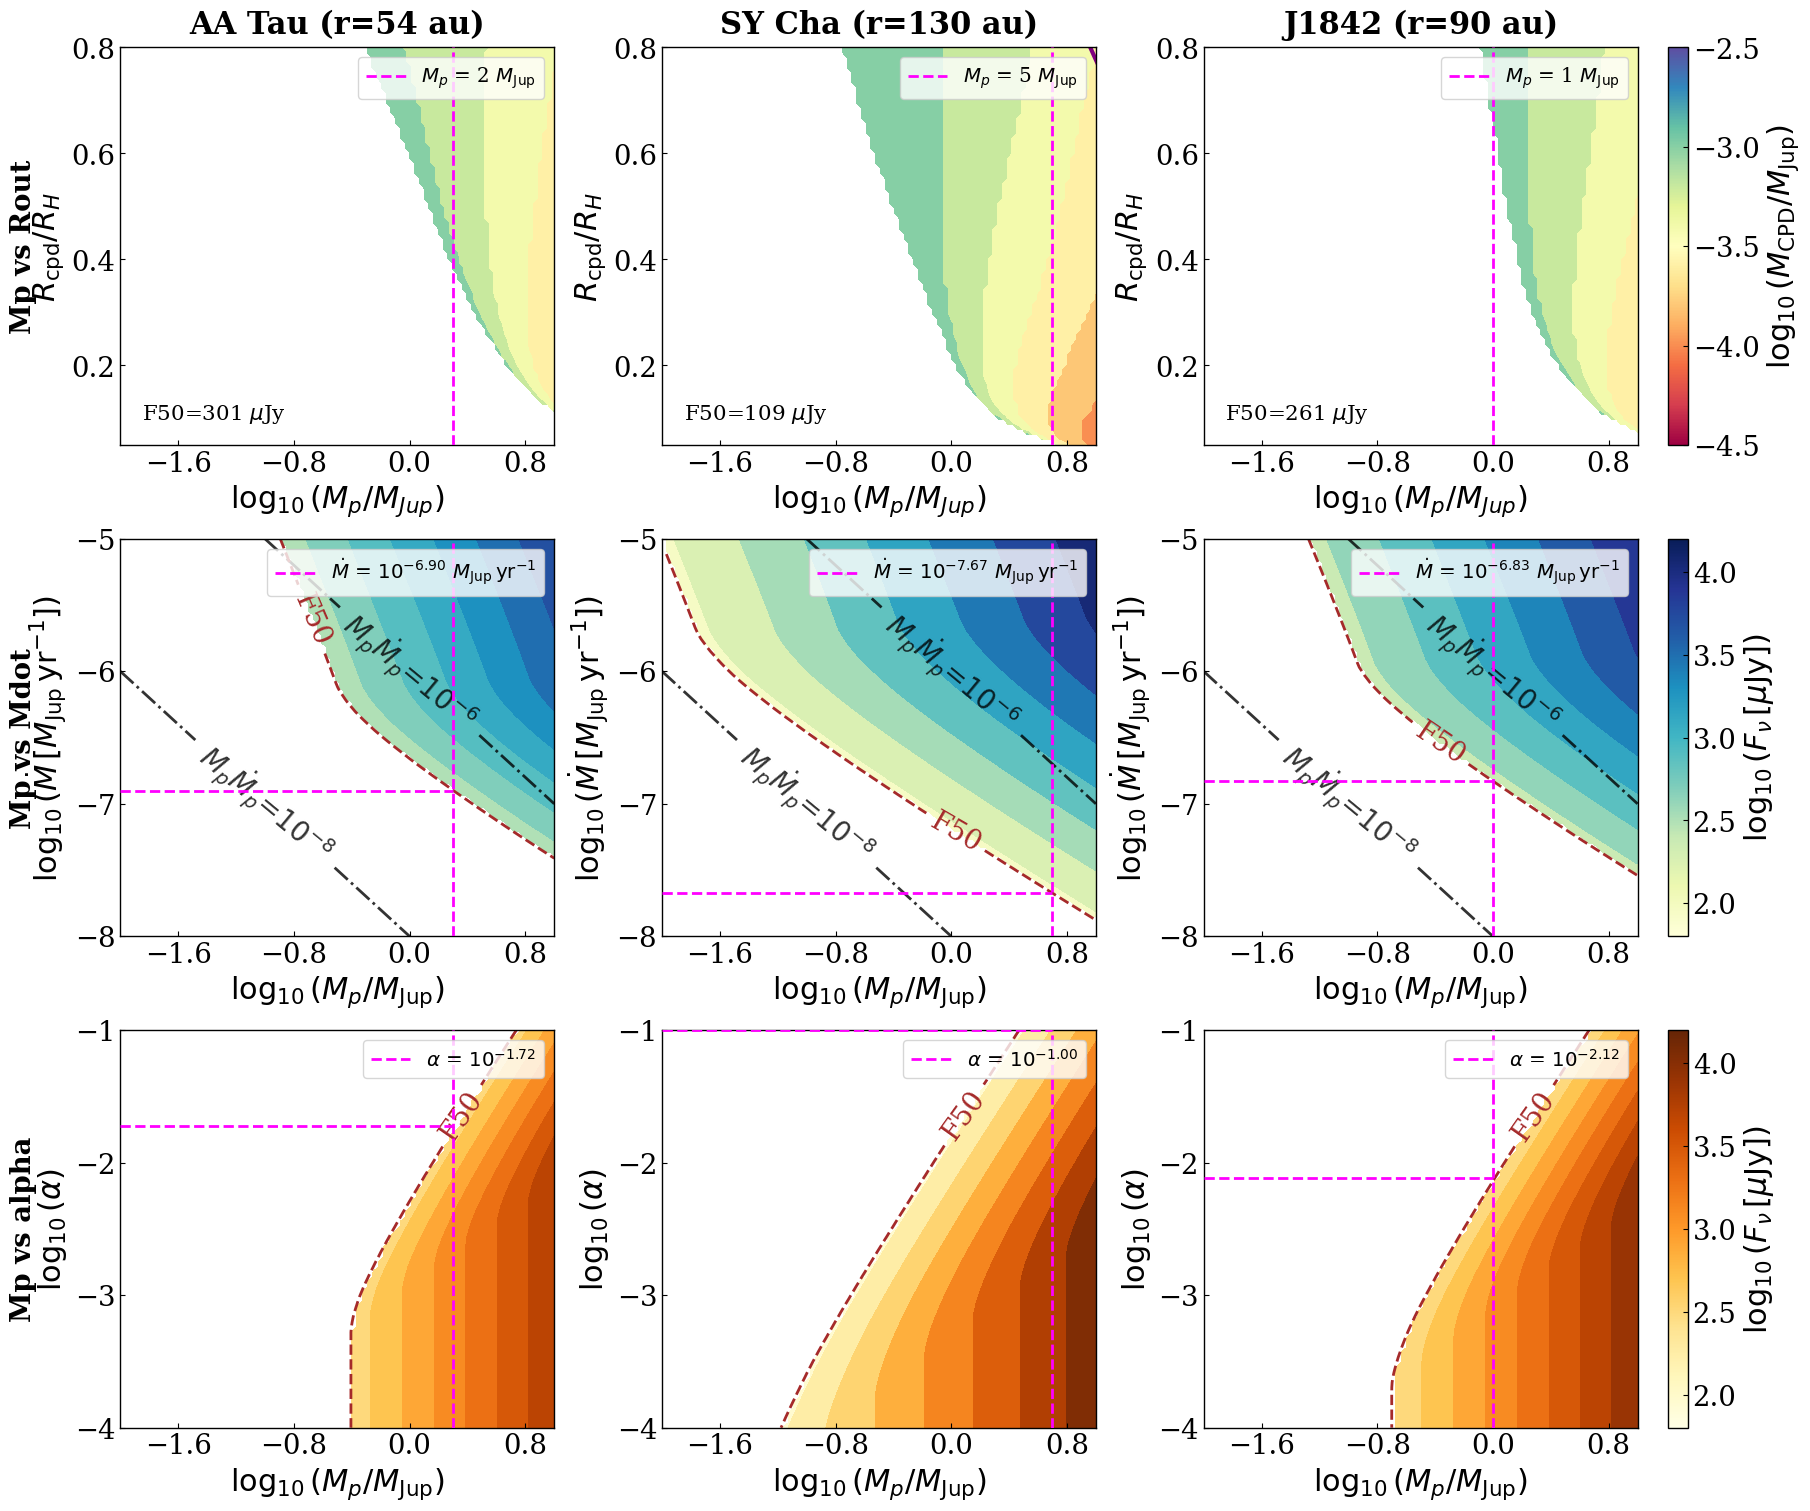

logMp_limit = 2.0149700075580714 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.591001109815947 xlim = (np.float64(-2.0), np.float64(1.0))


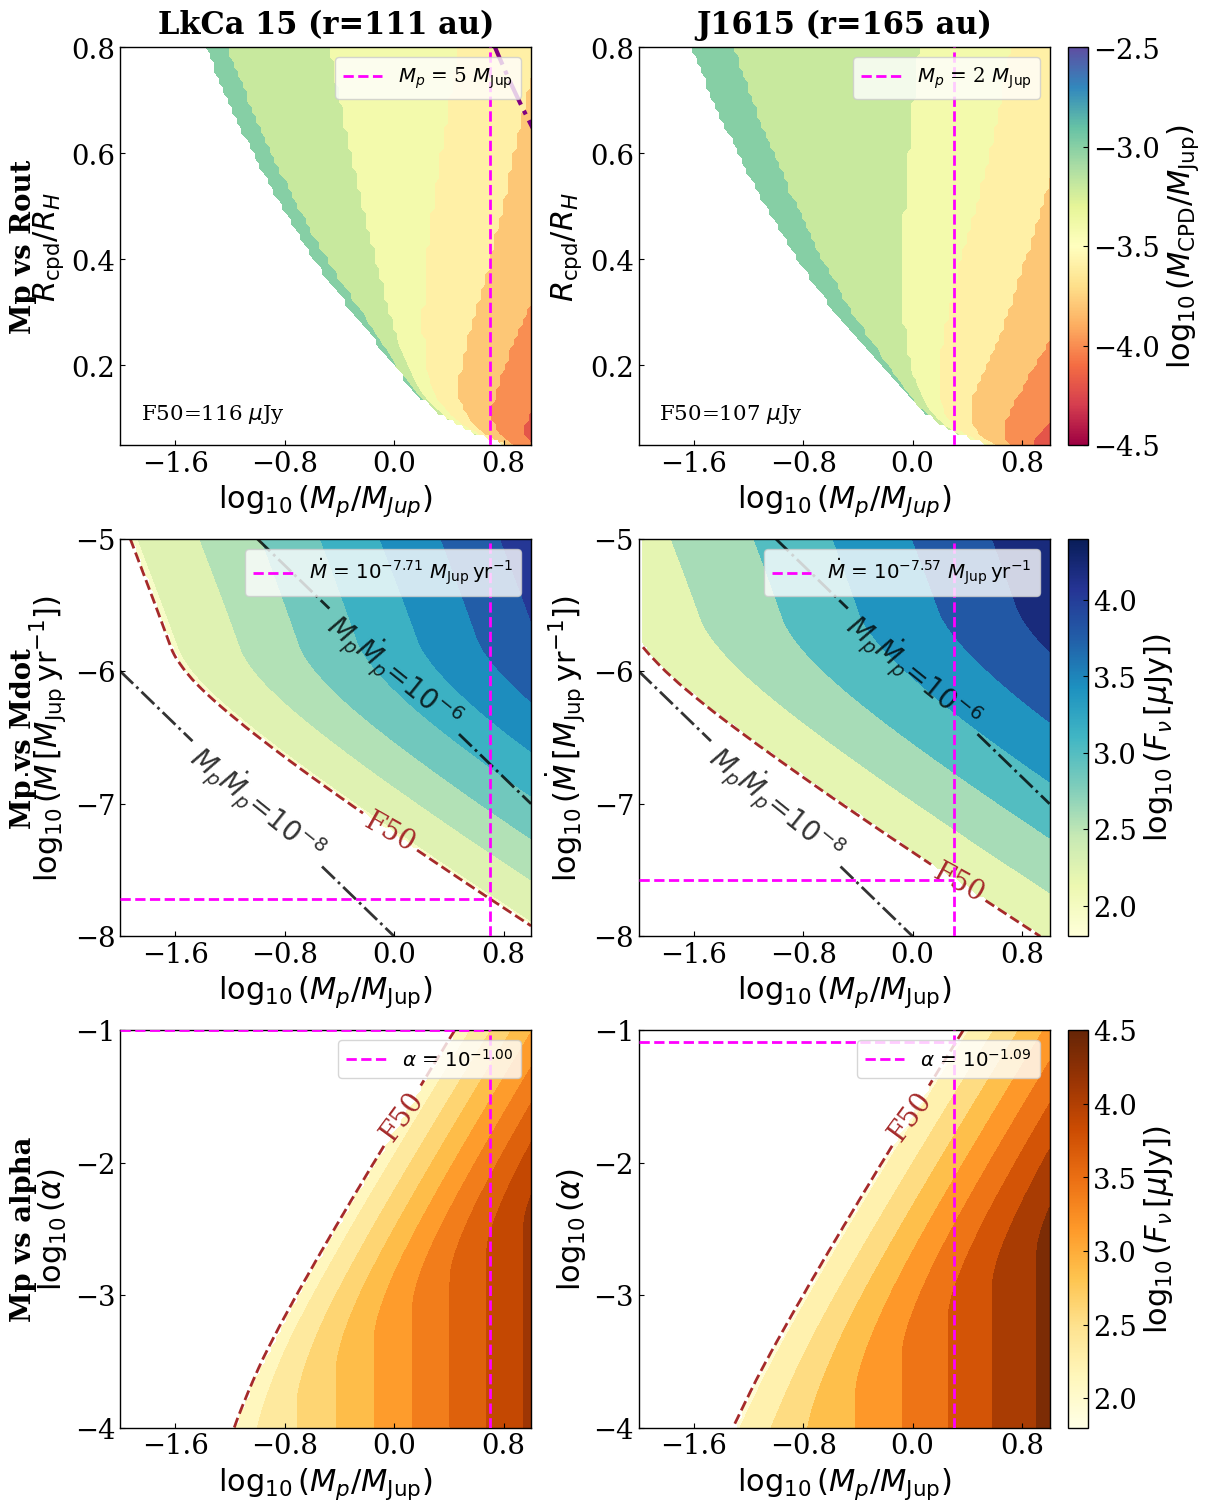

In [10]:
by_name = {s[0]: s for s in kink_sources_new}
group1 = [by_name["AA_Tau"], by_name["SY_Cha"], by_name["J1842"]]
group2 = [by_name["LkCa_15"], by_name["J1615"]]
plot_emission_grid(group1, mode="kink", planet_masses=kink_planet_mass_mjup, andrews_cmax=-2.5, andrews_cmin=-4.5, show_mp1_line=False)
plot_emission_grid(group2, mode="kink", planet_masses=kink_planet_mass_mjup, andrews_cmax=-2.5, andrews_cmin=-4.5, show_mp1_line=False)

In [11]:
# diagnostic: Mp x F50 intersection values used for the magenta horizontal
# lines above (Mdot for row 2, alpha for row 3)
for disk_name, disk_radius, sigma_ujy in kink_sources_new:
    if disk_name not in kink_planet_mass_mjup:
        continue
    mass = kink_planet_mass_mjup[disk_name]
    logmp = np.log10(mass)

    Mp_grid2, Mdot_grid, Flux_vals2, _ = get_zhu_mpmdot_grid(disk_name, disk_radius, "kink", alpha=1e-3)
    j2 = np.argmin(np.abs(np.log10(Mp_grid2) - logmp))
    order2 = np.argsort(Flux_vals2[:, j2])
    logmdot_F50 = np.interp(np.log10(sigma_ujy), np.log10(Flux_vals2[:, j2][order2]), np.log10(Mdot_grid[order2]))

    Mp_grid_alpha, alpha_grid, Flux_map, _ = get_zhu_mpalpha_grid(disk_name, disk_radius, "kink")
    j3 = np.argmin(np.abs(np.log10(Mp_grid_alpha) - logmp))
    order3 = np.argsort(Flux_map[:, j3])
    logalpha_F50 = np.interp(np.log10(sigma_ujy), np.log10(Flux_map[:, j3][order3]), np.log10(alpha_grid[order3]))

    print(f"{disk_name:10s} logMp={logmp:6.3f}  logMdot_F50={logmdot_F50:7.3f} (row2 y-range -8 to -5)  "
          f"logalpha_F50={logalpha_F50:7.3f} (row3 y-range -4 to -1)")

AA_Tau     logMp= 0.301  logMdot_F50= -6.900 (row2 y-range -8 to -5)  logalpha_F50= -1.725 (row3 y-range -4 to -1)
SY_Cha     logMp= 0.699  logMdot_F50= -7.672 (row2 y-range -8 to -5)  logalpha_F50= -1.000 (row3 y-range -4 to -1)
J1615      logMp= 0.301  logMdot_F50= -7.573 (row2 y-range -8 to -5)  logalpha_F50= -1.090 (row3 y-range -4 to -1)
LkCa_15    logMp= 0.699  logMdot_F50= -7.715 (row2 y-range -8 to -5)  logalpha_F50= -1.000 (row3 y-range -4 to -1)
J1842      logMp= 0.000  logMdot_F50= -6.828 (row2 y-range -8 to -5)  logalpha_F50= -2.117 (row3 y-range -4 to -1)


In [12]:
# diagnostic: Andrews-model heating dominance (accretion/boundary-layer vs
# planet's own irradiation vs stellar irradiation) for the kink candidates,
# at their assigned planet mass -- uses the same (M_star, rp, d_pc, Lstar)
# inputs as row 1's Mp-vs-Rout/R_Hill grid. Mdot left at its default (1.56
# Mjup/Myr -- compute_flux_map never varies it either, so this matches what
# row 1 actually plots) and Rout left at its default (R_Hill/3, the middle
# of row 1's 0.05-0.8 Rout/R_Hill range).
for disk_name, disk_radius, sigma_ujy in kink_sources_new:
    if disk_name not in kink_planet_mass_mjup:
        continue
    mass = kink_planet_mass_mjup[disk_name]

    out = Andrew_model.calculate_disk_properties_Andrews(
        M_star=disk_arr[disk_name][1], Mp=mass, rp=disk_radius,
        d_pc=disk_arr[disk_name][2], Lstar=disk_arr[disk_name][3],
    )
    T4_acc, T4_p, T4_star = out["T_irr"] ** 4, out["T_irr_p"] ** 4, out["T_irr_star"] ** 4
    T4_tot = T4_acc + T4_p + T4_star
    frac_acc, frac_p, frac_star = T4_acc / T4_tot, T4_p / T4_tot, T4_star / T4_tot

    labels = ["accretion", "planet irrad.", "stellar irrad."]
    dom_in = labels[np.argmax([frac_acc[0], frac_p[0], frac_star[0]])]
    dom_out = labels[np.argmax([frac_acc[-1], frac_p[-1], frac_star[-1]])]

    print(f"{disk_name:10s} Mp={mass}  R_in={out['R_AU'][0]:.3f} au: {dom_in:14s} "
          f"(acc={frac_acc[0]:.2f} planet={frac_p[0]:.2f} star={frac_star[0]:.2f})  |  "
          f"R_out={out['R_AU'][-1]:.3f} au: {dom_out:14s} "
          f"(acc={frac_acc[-1]:.2f} planet={frac_p[-1]:.2f} star={frac_star[-1]:.2f})")

AA_Tau     Mp=2  R_in=0.001 au: planet irrad.  (acc=0.41 planet=0.59 star=0.00)  |  R_out=1.675 au: stellar irrad. (acc=0.02 planet=0.33 star=0.65)
SY_Cha     Mp=5  R_in=0.001 au: planet irrad.  (acc=0.19 planet=0.81 star=0.00)  |  R_out=5.519 au: planet irrad.  (acc=0.01 planet=0.78 star=0.21)
J1615      Mp=2  R_in=0.001 au: planet irrad.  (acc=0.41 planet=0.59 star=0.00)  |  R_out=4.528 au: stellar irrad. (acc=0.01 planet=0.40 star=0.59)
LkCa_15    Mp=5  R_in=0.001 au: planet irrad.  (acc=0.19 planet=0.81 star=0.00)  |  R_out=4.134 au: planet irrad.  (acc=0.01 planet=0.72 star=0.28)
J1842      Mp=1  R_in=0.001 au: accretion      (acc=0.72 planet=0.28 star=0.00)  |  R_out=2.002 au: stellar irrad. (acc=0.03 planet=0.18 star=0.79)


## Kink candidates: uv-fixed runs at the Table 2 radii

These are the F50 values (criterion B) from `HPC_kink_spartan/assess_kink0.ipynb`. Each one combines 10 uv-fixed runs per kink (`_kink0_uvfix` + `_kink0_rep1`–`rep9`), giving 500 mocks per flux bin. The injection position is the radius r_planet from Pinte+2025 Table 2 and the Figure 5 azimuth. They replace the older kink entries above, which used other radii and the uv-scaling bug.

- **AA Tau:** recovery is already about 0.8 at the lowest flux bin (43 µJy = 1 × RMS), so its F50 is only an upper limit (≤ 43 µJy). This is caused by a positive residual in its injection zone. Instead of that upper limit, the model flux used here is the flux of this competing peak: 139 µJy, the median brightest-pixel flux (`recover_loop.py`) of the most common criterion-A failure position (r = 0.630", az = −143°; 316 of 932 failures) in `HPC_kink_spartan/AA_Tau_kink0_uvfix/recoveries/AA_Tau_gap2_recoveries.combined.txt`. The Andrews caches made with 43 µJy were renamed to `*_F43.npz`, since the cache file name does not include the flux.
- **Planet masses:** Pinte+2025 Table 2. These are now fitted at the same radius as our injection position.

logMp_limit = 2.0728512857133032 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.778796719721006 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 1.769367860954848 xlim = (np.float64(-2.0), np.float64(1.0))


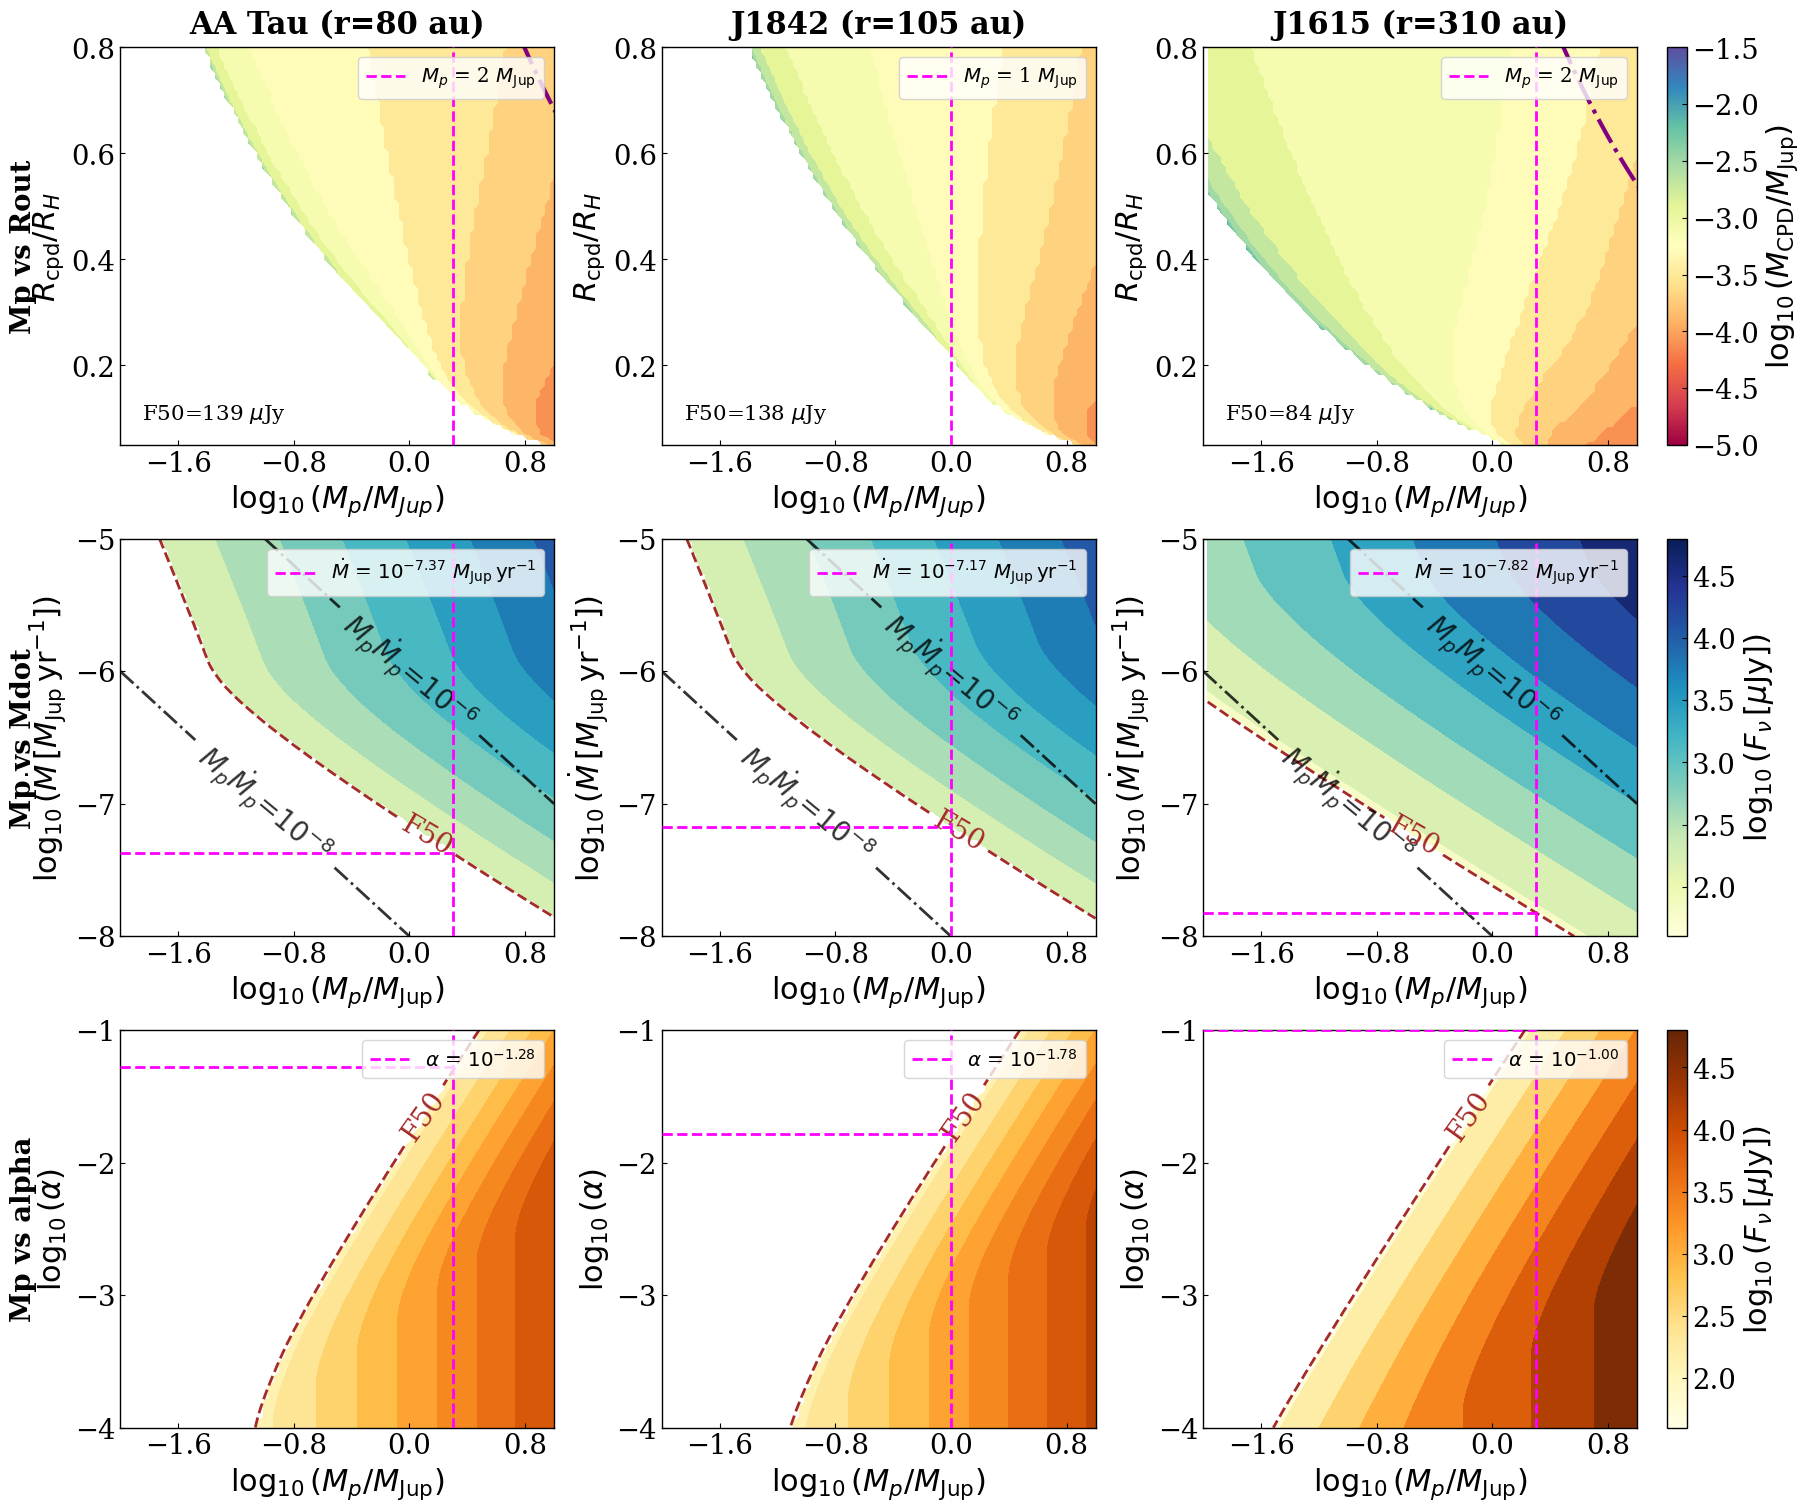

logMp_limit = 1.0103052187832255 xlim = (np.float64(-2.0), np.float64(1.0))
logMp_limit = 2.1424271995705677 xlim = (np.float64(-2.0), np.float64(1.0))


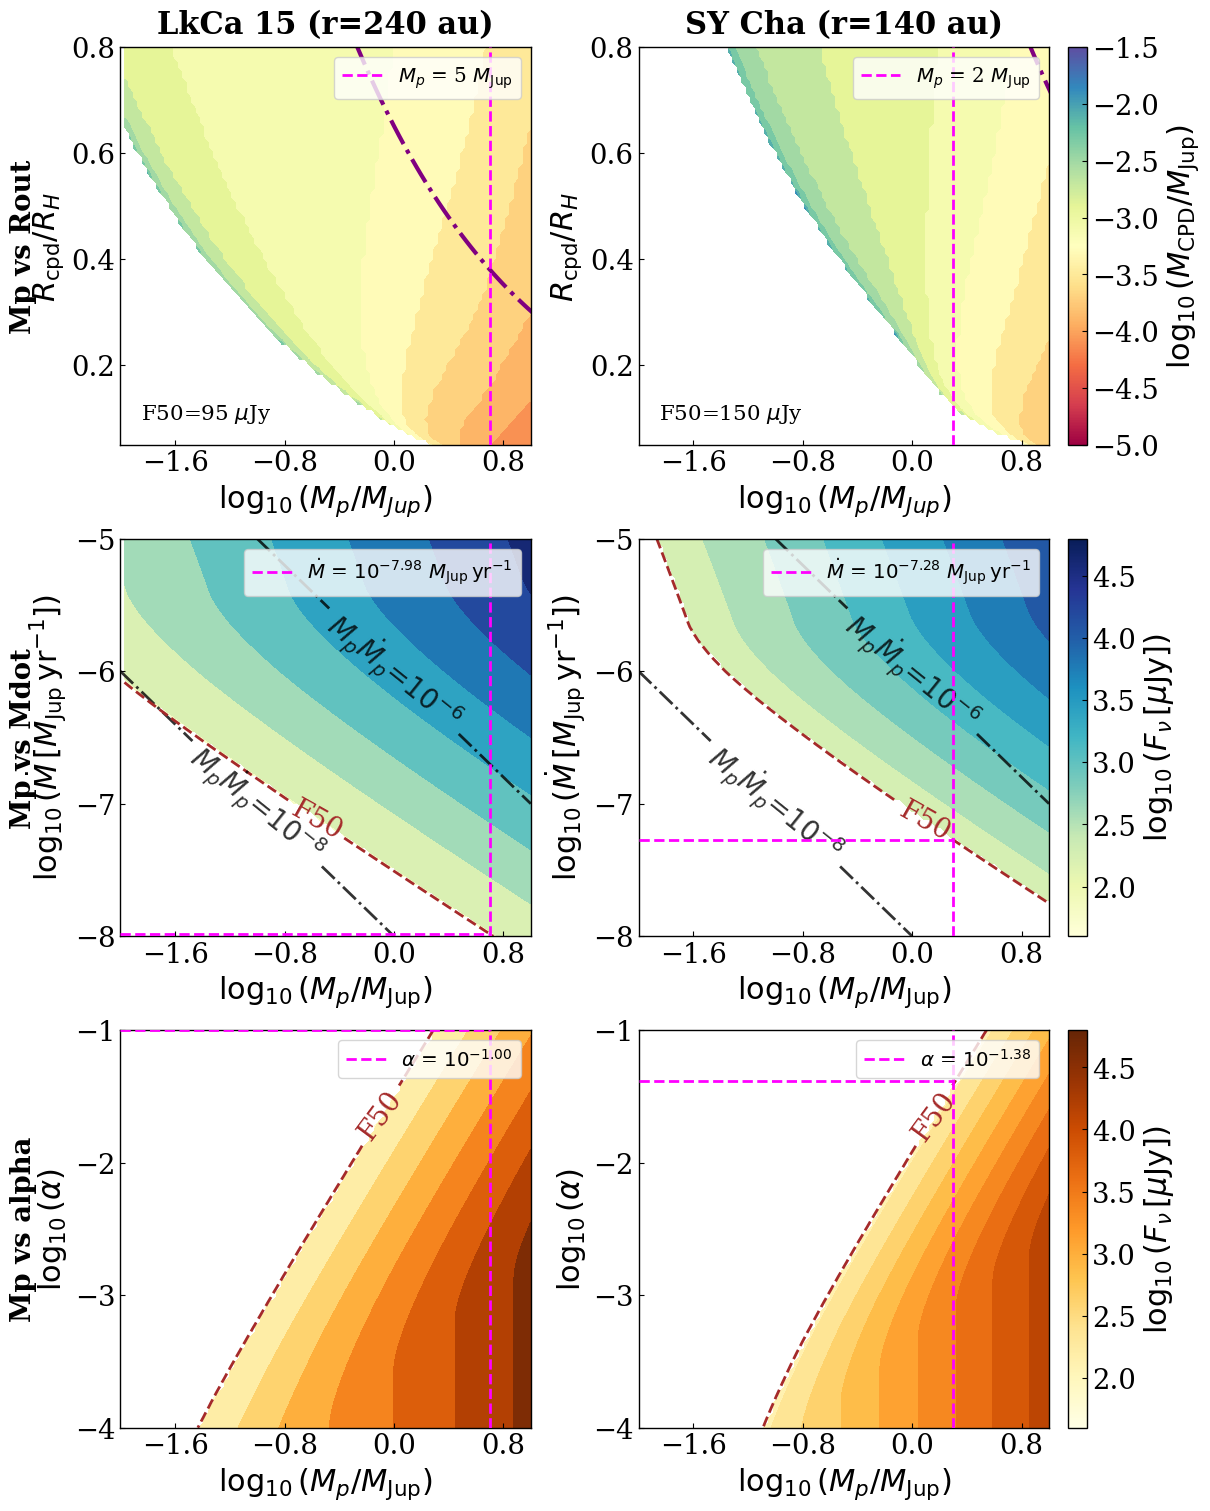

In [13]:
# Format: [disk_name, radius_au, F50_ujy] -- radius = rkink * distance, F50 = criterion B (assess_kink0.ipynb, 10 uvfix runs)
kink_sources_uvfix = [
    ["AA_Tau",   80, 139.0],   # competing-peak flux (F50 is only an upper limit, <= 43 uJy) -- see markdown above
    ["SY_Cha",  140, 150.4],
    ["J1615",   310,  84.5],
    ["LkCa_15", 240,  94.8],
    ["J1842",   105, 137.5],
]

# planet masses, Pinte+2025 Table 2
kink_planet_mass_table2 = {"AA_Tau": 2, "SY_Cha": 2, "J1615": 2, "LkCa_15": 5, "J1842": 1}

# CPD-mass search extended to 10^-1.5 M_Jup (default 10^-3): SY Cha needs > 10^-3 M_Jup below ~1.3 M_Jup,
# which left a flat white edge in row 1 instead of the physical (Rout > R_planet) boundary
by_name = {s[0]: s for s in kink_sources_uvfix}
plot_emission_grid([by_name["AA_Tau"], by_name["J1842"], by_name["J1615"]], mode="kink_uvfix",
                   planet_masses=kink_planet_mass_table2, andrews_cmax=-1.5, andrews_cmin=-5, andrews_mcpd_max=-1.5, show_mp1_line=False)
plot_emission_grid([by_name["LkCa_15"], by_name["SY_Cha"]], mode="kink_uvfix",
                   planet_masses=kink_planet_mass_table2, andrews_cmax=-1.5, andrews_cmin=-5, andrews_mcpd_max=-1.5, show_mp1_line=False)

In [14]:
# Mp x F50 intersections at the Table 2 planet mass (Mdot for row 2, alpha for row 3)
for disk_name, disk_radius, sigma_ujy in kink_sources_uvfix:
    logmp = np.log10(kink_planet_mass_table2[disk_name])

    Mp_grid2, Mdot_grid, Flux_vals2, _ = get_zhu_mpmdot_grid(disk_name, disk_radius, "kink_uvfix", alpha=1e-3)
    j2 = np.argmin(np.abs(np.log10(Mp_grid2) - logmp))
    order2 = np.argsort(Flux_vals2[:, j2])
    logmdot_F50 = np.interp(np.log10(sigma_ujy), np.log10(Flux_vals2[:, j2][order2]), np.log10(Mdot_grid[order2]))

    Mp_grid_alpha, alpha_grid, Flux_map, _ = get_zhu_mpalpha_grid(disk_name, disk_radius, "kink_uvfix")
    j3 = np.argmin(np.abs(np.log10(Mp_grid_alpha) - logmp))
    order3 = np.argsort(Flux_map[:, j3])
    logalpha_F50 = np.interp(np.log10(sigma_ujy), np.log10(Flux_map[:, j3][order3]), np.log10(alpha_grid[order3]))

    print(f"{disk_name:10s} r={disk_radius:3d} au  F50={sigma_ujy:6.1f} uJy  logMp={logmp:6.3f}  "
          f"logMdot_F50={logmdot_F50:7.3f} (row2 y-range -8 to -5)  logalpha_F50={logalpha_F50:7.3f} (row3 y-range -4 to -1)")

AA_Tau     r= 80 au  F50= 139.0 uJy  logMp= 0.301  logMdot_F50= -7.375 (row2 y-range -8 to -5)  logalpha_F50= -1.277 (row3 y-range -4 to -1)
SY_Cha     r=140 au  F50= 150.4 uJy  logMp= 0.301  logMdot_F50= -7.275 (row2 y-range -8 to -5)  logalpha_F50= -1.382 (row3 y-range -4 to -1)
J1615      r=310 au  F50=  84.5 uJy  logMp= 0.301  logMdot_F50= -7.823 (row2 y-range -8 to -5)  logalpha_F50= -1.000 (row3 y-range -4 to -1)
LkCa_15    r=240 au  F50=  94.8 uJy  logMp= 0.699  logMdot_F50= -7.980 (row2 y-range -8 to -5)  logalpha_F50= -1.000 (row3 y-range -4 to -1)
J1842      r=105 au  F50= 137.5 uJy  logMp= 0.000  logMdot_F50= -7.173 (row2 y-range -8 to -5)  logalpha_F50= -1.783 (row3 y-range -4 to -1)
